# Volume Conduction and Spurious Torus Recovery in LFP Manifolds

## Motivation

EEG/LFP signals suffer from **volume conduction**: each electrode records a *linear mixture* of activities from multiple neural sources. When we apply delay embedding (Takens' theorem) to reconstruct state-space manifolds, we must ask:

> *Does the recovered torus represent a true multi-rhythmic neural manifold, or is it an artifact of spatially mixing independent oscillatory sources?*

If a single neural population generates quasi-periodic dynamics with $k$ incommensurate frequencies, the underlying attractor is a $k$-torus — this is the **true** manifold we want to recover. However, if $k$ *independent* single-frequency sources are mixed at the sensor level, the resulting signal also looks quasi-periodic, and delay embedding may produce a **spurious torus** that reflects mixing geometry rather than neural dynamics.

This notebook investigates the problem through controlled simulations:

| Scenario | Sources | Sensor Signal | Expected Manifold |
|:---|:---|:---|:---|
| **A** — True torus | 1 source, 2 rhythms | Quasi-periodic | Genuine 2-torus |
| **B** — Spurious torus | 2 sources, 1 rhythm each | Mixture looks quasi-periodic | Spurious 2-torus (mixing artifact) |
| **C** — Spatial diagnostics | Multi-channel recordings | Varying mixing weights | Cross-channel consistency check |

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal as sp_signal

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from NeuralFieldManifold.embedders import embed

# ── Plot style ──
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300,
    'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'lines.linewidth': 1.8, 'axes.spines.top': False, 'axes.spines.right': False,
})

print('Imports OK')

Imports OK


---
## 1. Simulation Primitives

We build three elementary components:

1. **Oscillatory source** — a narrow-band signal at frequency $f$ (damped oscillator + noise)
2. **Quasi-periodic source** — a single process with two incommensurate frequencies (genuine torus generator)
3. **Mixing / forward model** — a matrix $\mathbf{A} \in \mathbb{R}^{N_{\text{ch}} \times N_{\text{src}}}$ that maps source activities to channel recordings via volume conduction

In [208]:
# ── 1a. Single oscillatory source ──

def oscillatory_source(f, fs, n_samples, amplitude=1.0, damping=0.995, noise_std=0.05, seed=None):
    """Generate a narrow-band oscillatory source using a damped AR(2) process."""
    rng = np.random.default_rng(seed)
    theta = 2 * np.pi * f / fs
    a1 = 2 * damping * np.cos(theta)
    a2 = -(damping ** 2)
    
    x = np.zeros(n_samples)
    eps = rng.normal(0, noise_std, n_samples)
    for t in range(2, n_samples):
        x[t] = a1 * x[t-1] + a2 * x[t-2] + eps[t]
    
    x = amplitude * x / (np.std(x) + 1e-12)
    return x


# ── 1b. Quasi-periodic source (true torus generator) ──

def quasiperiodic_source(f1, f2, fs, n_samples, r1=0.995, r2=0.990, noise_std=0.05, seed=None):
    """A single AR(4) source with two complex-conjugate pole pairs at incommensurate frequencies."""
    rng = np.random.default_rng(seed)
    theta1 = 2 * np.pi * f1 / fs
    theta2 = 2 * np.pi * f2 / fs
    
    poles = [
        r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
        r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2),
    ]
    ar_poly = np.poly(poles)
    coeffs = np.real(-ar_poly[1:])
    p = len(coeffs)
    
    x = np.zeros(n_samples)
    eps = rng.normal(0, noise_std, n_samples)
    x[:p] = rng.normal(0, noise_std, p)
    for t in range(p, n_samples):
        x[t] = sum(coeffs[i] * x[t - i - 1] for i in range(p)) + eps[t]
    
    x = x / (np.std(x) + 1e-12)
    return x


# ── 1c. Volume conduction mixing matrix ──

def make_mixing_matrix(n_channels, n_sources, spatial_spread=1.0, seed=None):
    """Create a mixing matrix that models volume conduction with distance-dependent attenuation."""
    rng = np.random.default_rng(seed)
    
    src_locs = np.linspace(0, 1, n_sources)
    ch_locs = np.linspace(0, 1, n_channels)
    
    dist = np.abs(ch_locs[:, None] - src_locs[None, :])
    A = np.exp(-dist**2 / (2 * spatial_spread**2))
    A = A / A.sum(axis=1, keepdims=True)
    
    return A, src_locs, ch_locs


print('Simulation primitives defined.')

Simulation primitives defined.


---
## 2. Scenario A — True Torus: Single Source with Two Rhythms

A single neural population generates quasi-periodic activity at two incommensurate frequencies $f_1$ and $f_2$. This process lives on a 2-torus:

$$\mathcal{M} = \mathbb{T}^2 = S^1 \times S^1$$

Delay embedding of any channel should recover this torus, because the torus is an intrinsic property of the source dynamics — volume conduction (a linear operation) preserves the topology.

In [209]:
# ── Parameters ──
fs = 500        # Sampling frequency (Hz)
T = 10.0        # Duration (seconds)
n_samples = int(fs * T)
n_channels = 8  # Number of electrodes

# Source: one quasi-periodic AR(4) process with two frequencies
f1_true, f2_true = 10.0, 23.0  # Hz (incommensurate)

source_true_torus = quasiperiodic_source(
    f1_true, f2_true, fs, n_samples, r1=0.995, r2=0.990, noise_std=0.03, seed=42
)

# Volume conduction: 1 source broadcast to 8 channels with distance decay
rng = np.random.default_rng(0)
sensor_noise_std = 0.05
channels_A = np.array([
    source_true_torus + sensor_noise_std * rng.normal(size=n_samples)
    for _ in range(n_channels)
])

print(f'Source shape: {source_true_torus.shape}')
print(f'Channels shape: {channels_A.shape}')

Source shape: (5000,)
Channels shape: (8, 5000)


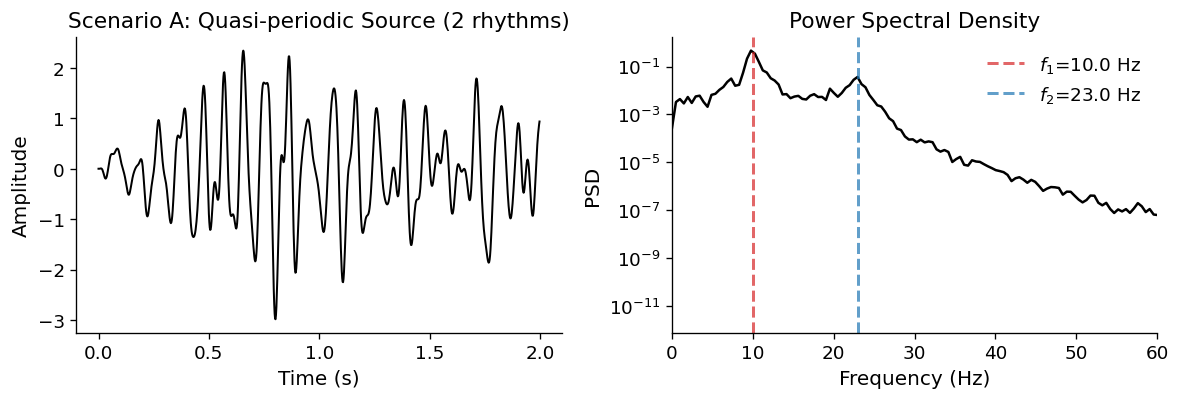

In [210]:
# ── Visualize source PSD ──
freqs_psd, Pxx = sp_signal.welch(source_true_torus, fs=fs, nperseg=1024)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

t_plot = np.arange(n_samples) / fs
axes[0].plot(t_plot[:1000], source_true_torus[:1000], color='black', lw=1.2)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Scenario A: Quasi-periodic Source (2 rhythms)')

axes[1].semilogy(freqs_psd, Pxx, color='black', lw=1.5)
axes[1].axvline(f1_true, color='tab:red', ls='--', alpha=0.7, label=f'$f_1$={f1_true} Hz')
axes[1].axvline(f2_true, color='tab:blue', ls='--', alpha=0.7, label=f'$f_2$={f2_true} Hz')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD')
axes[1].set_title('Power Spectral Density')
axes[1].set_xlim([0, 60])
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

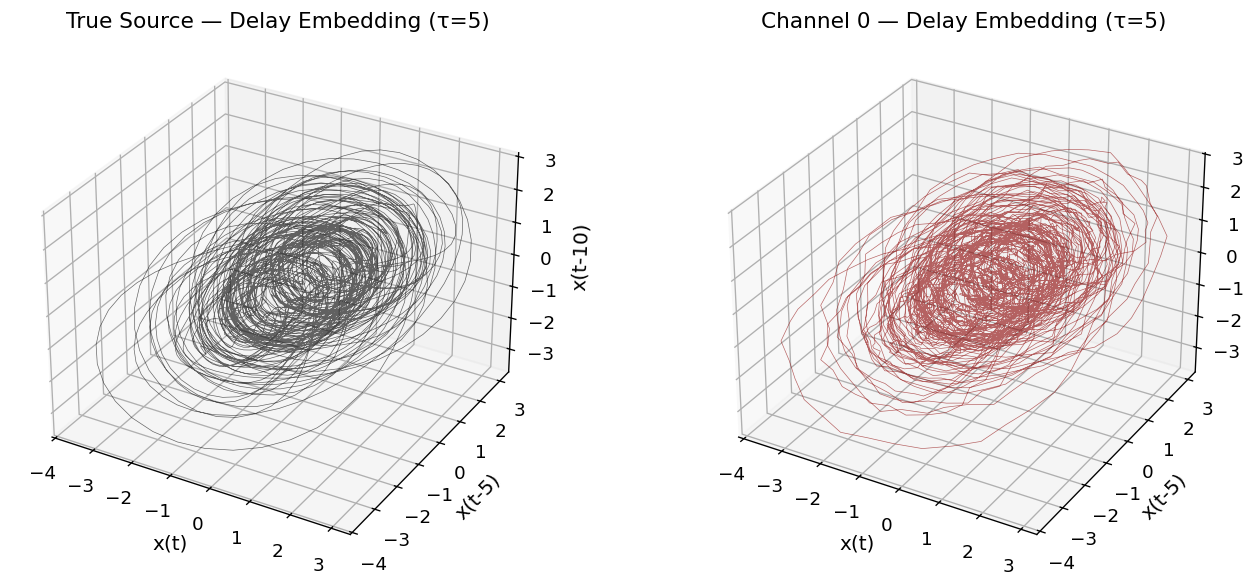

✓ Both embeddings show the same torus — volume conduction preserves topology for true quasi-periodic sources.


In [211]:
# ── Delay embedding of true source → torus ──
tau_A = 5  # delay in samples
m = 3      # embedding dimension

X3_source = np.array(embed(source_true_torus, m, tau_A))

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X3_source[:, 0], X3_source[:, 1], X3_source[:, 2], 
         color='black', lw=0.4, alpha=0.6)
ax1.set_title(f'True Source — Delay Embedding (τ={tau_A})')
ax1.set_xlabel('x(t)'); ax1.set_ylabel(f'x(t-{tau_A})'); ax1.set_zlabel(f'x(t-{2*tau_A})')

X3_ch0 = np.array(embed(channels_A[0], m, tau_A))
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(X3_ch0[:, 0], X3_ch0[:, 1], X3_ch0[:, 2], 
         color='darkred', lw=0.4, alpha=0.6)
ax2.set_title(f'Channel 0 — Delay Embedding (τ={tau_A})')
ax2.set_xlabel('x(t)'); ax2.set_ylabel(f'x(t-{tau_A})'); ax2.set_zlabel(f'x(t-{2*tau_A})')

plt.tight_layout()
plt.show()

print('✓ Both embeddings show the same torus — volume conduction preserves topology for true quasi-periodic sources.')

**Figure 1 — True torus under delay embedding.** *Left*: The quasi-periodic AR(4) source with two incommensurate frequencies ($f_1 = 10$ Hz, $f_2 = 23$ Hz) is delay-embedded in $\mathbb{R}^3$. The resulting attractor is a 2-torus ($\mathbb{T}^2 = S^1 \times S^1$), confirming that the source dynamics are genuinely quasi-periodic. *Right*: A sensor channel that receives this source through volume conduction (linear mixing + additive sensor noise) recovers the **same** torus. This is expected — Takens' embedding theorem guarantees that a generic observation function of a dynamical system preserves the attractor topology, and linear mixing is a special case.

> **Goal**: Establish the ground truth — when the torus is intrinsic to the source, it survives volume conduction.

**Key finding**: When the torus is an intrinsic property of the source dynamics, *every* channel that receives the source will recover the same topological structure under delay embedding. Linear mixing (volume conduction) is a diffeomorphism and therefore preserves the manifold topology.

---
## 3. Scenario B — Spurious Torus: Two Independent Sources Mixed at the Sensor

Now imagine two *independent* neural populations, each generating a single oscillatory rhythm:
- Source 1: narrow-band oscillator at $f_1 = 10$ Hz  
- Source 2: narrow-band oscillator at $f_2 = 23$ Hz

Each source individually lives on a **circle** ($S^1$), not a torus. But an electrode that records a mixture of both sources sees a quasi-periodic-looking signal — and delay embedding can produce a structure that *looks* like a torus.

This is the **spurious torus**: a mixing artifact, not a genuine neural manifold.

In [212]:
# ── Two independent single-rhythm sources ──
src1 = oscillatory_source(f=10.0, fs=fs, n_samples=n_samples, damping=0.995, noise_std=0.03, seed=100)
src2 = oscillatory_source(f=23.0, fs=fs, n_samples=n_samples, damping=0.995, noise_std=0.03, seed=200)

sources_B = np.stack([src1, src2], axis=0)

A_mix, src_locs, ch_locs = make_mixing_matrix(
    n_channels=n_channels, n_sources=2, spatial_spread=0.3, seed=42
)

channels_B = A_mix @ sources_B + sensor_noise_std * rng.normal(size=(n_channels, n_samples))

print(f'Mixing matrix A:\n{np.round(A_mix, 3)}\n')
print(f'Source 1 dominates channels near position {src_locs[0]:.2f}')
print(f'Source 2 dominates channels near position {src_locs[1]:.2f}')

Mixing matrix A:
[[0.996 0.004]
 [0.981 0.019]
 [0.915 0.085]
 [0.689 0.311]
 [0.311 0.689]
 [0.085 0.915]
 [0.019 0.981]
 [0.004 0.996]]

Source 1 dominates channels near position 0.00
Source 2 dominates channels near position 1.00


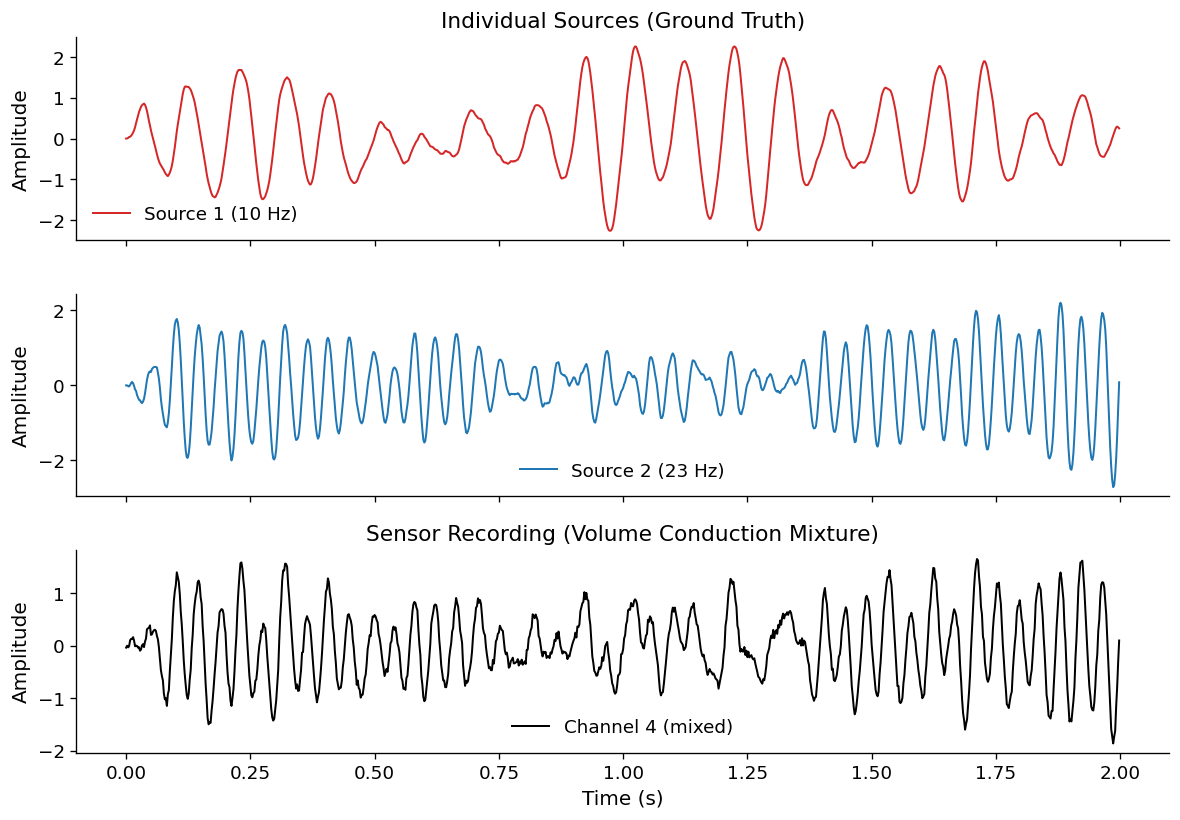

In [213]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

t_plot = np.arange(1000) / fs

axes[0].plot(t_plot, src1[:1000], color='tab:red', lw=1.2, label='Source 1 (10 Hz)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(frameon=False)
axes[0].set_title('Individual Sources (Ground Truth)')

axes[1].plot(t_plot, src2[:1000], color='tab:blue', lw=1.2, label='Source 2 (23 Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].legend(frameon=False)

mid_ch = n_channels // 2
axes[2].plot(t_plot, channels_B[mid_ch, :1000], color='black', lw=1.2, 
             label=f'Channel {mid_ch} (mixed)')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')
axes[2].legend(frameon=False)
axes[2].set_title('Sensor Recording (Volume Conduction Mixture)')

plt.tight_layout()
plt.show()

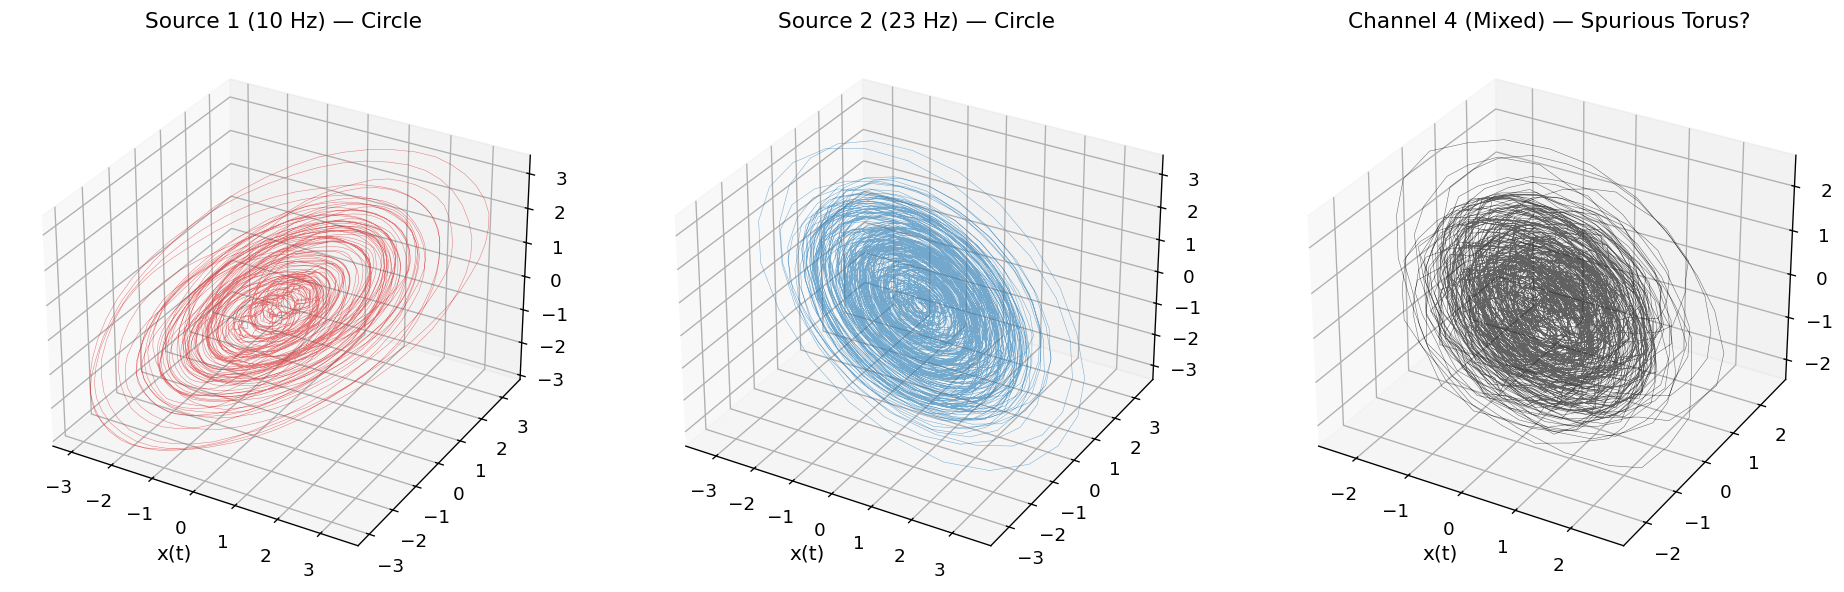

Individual sources live on circles (S¹). The mixture can look like a torus (T²) — a mixing artifact!


In [214]:
tau_B = 5

X3_src1 = np.array(embed(src1, m, tau_B))
X3_src2 = np.array(embed(src2, m, tau_B))
X3_mixed = np.array(embed(channels_B[mid_ch], m, tau_B))

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X3_src1[:, 0], X3_src1[:, 1], X3_src1[:, 2], 
         color='tab:red', lw=0.3, alpha=0.6)
ax1.set_title('Source 1 (10 Hz) — Circle')
ax1.set_xlabel('x(t)')

ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(X3_src2[:, 0], X3_src2[:, 1], X3_src2[:, 2], 
         color='tab:blue', lw=0.3, alpha=0.6)
ax2.set_title('Source 2 (23 Hz) — Circle')
ax2.set_xlabel('x(t)')

ax3 = fig.add_subplot(133, projection='3d')
ax3.plot(X3_mixed[:, 0], X3_mixed[:, 1], X3_mixed[:, 2], 
         color='black', lw=0.3, alpha=0.6)
ax3.set_title(f'Channel {mid_ch} (Mixed) — Spurious Torus?')
ax3.set_xlabel('x(t)')

plt.tight_layout()
plt.show()

print('Individual sources live on circles (S¹). The mixture can look like a torus (T²) — a mixing artifact!')

**Figure 2 — Spurious torus from volume conduction mixing.** *Left & Center*: Each independent source (10 Hz and 23 Hz damped oscillators) embeds to a **circle** ($S^1$), which is the correct attractor for a single-frequency oscillator. *Right*: A sensor channel that records a *linear mixture* of both sources embeds to a structure resembling a 2-torus — the **spurious torus**. This apparent $\mathbb{T}^2$ is not an intrinsic dynamical object; it is the Cartesian product $S^1 \times S^1$ created by the mixing geometry, not by genuinely coupled quasi-periodic dynamics within a single neural population.

> **Key point**: Delay embedding cannot distinguish between (i) a single source with two rhythms and (ii) two independent sources mixed at the sensor — both produce torus-like structures. An additional spatial diagnostic is needed.

---
## 4. Cross-Channel Manifold Comparison

A critical diagnostic: if the torus is **real** (Scenario A), every channel should show the *same* manifold geometry (up to a diffeomorphism). If it is **spurious** (Scenario B), channels with different mixing weights will show *different* manifold shapes — channels near Source 1 see a more circular structure, while channels in the middle see a torus.

This cross-channel spatial consistency is a key test.

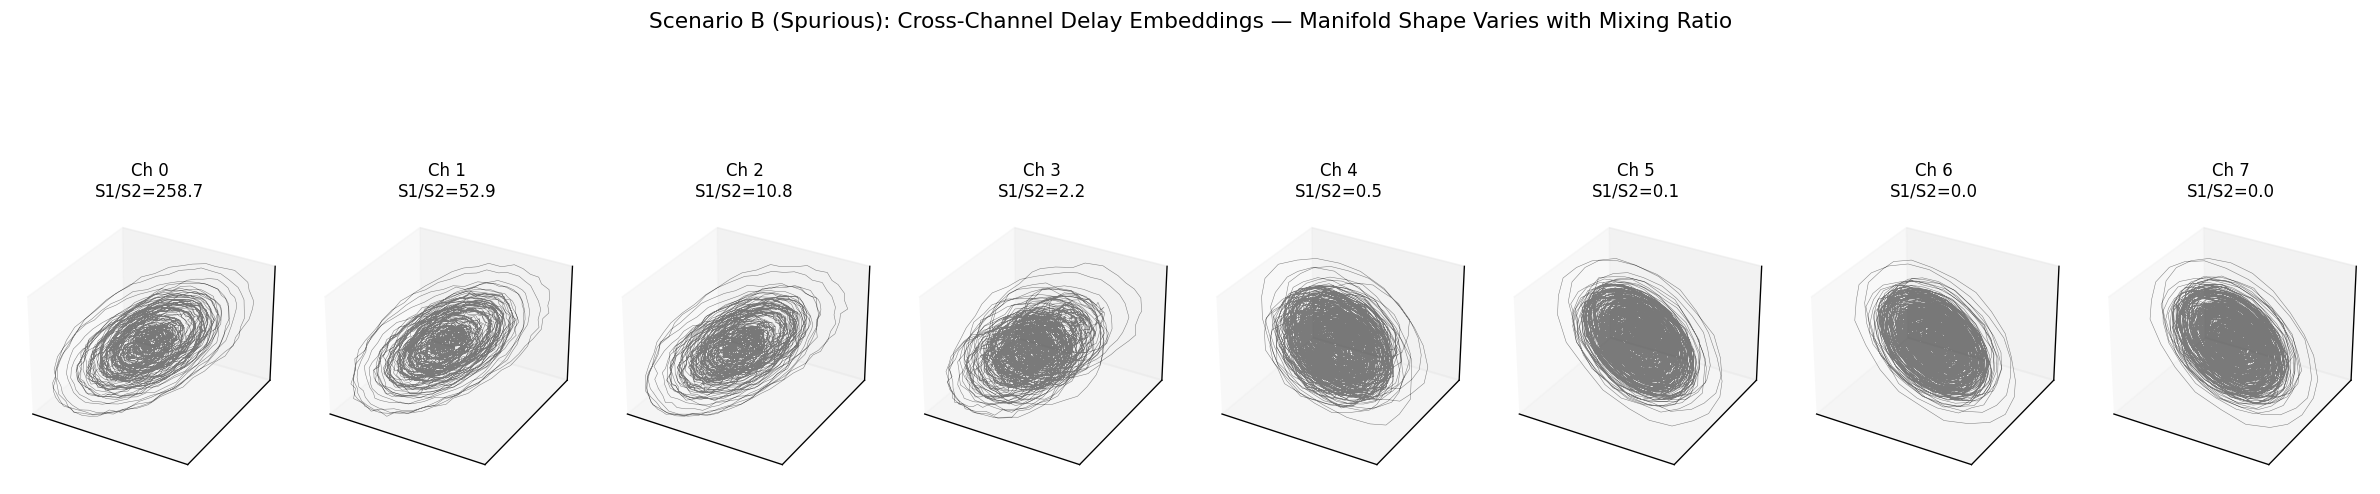

In [215]:
tau_cross = 5

fig = plt.figure(figsize=(20, 5))

for ch_idx in range(n_channels):
    ax = fig.add_subplot(1, n_channels, ch_idx + 1, projection='3d')
    X3_ch = np.array(embed(channels_B[ch_idx], m, tau_cross))
    ax.plot(X3_ch[:, 0], X3_ch[:, 1], X3_ch[:, 2], 
            color='black', lw=0.3, alpha=0.5)
    ratio = A_mix[ch_idx, 0] / (A_mix[ch_idx, 1] + 1e-12)
    ax.set_title(f'Ch {ch_idx}\nS1/S2={ratio:.1f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.suptitle('Scenario B (Spurious): Cross-Channel Delay Embeddings — Manifold Shape Varies with Mixing Ratio', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

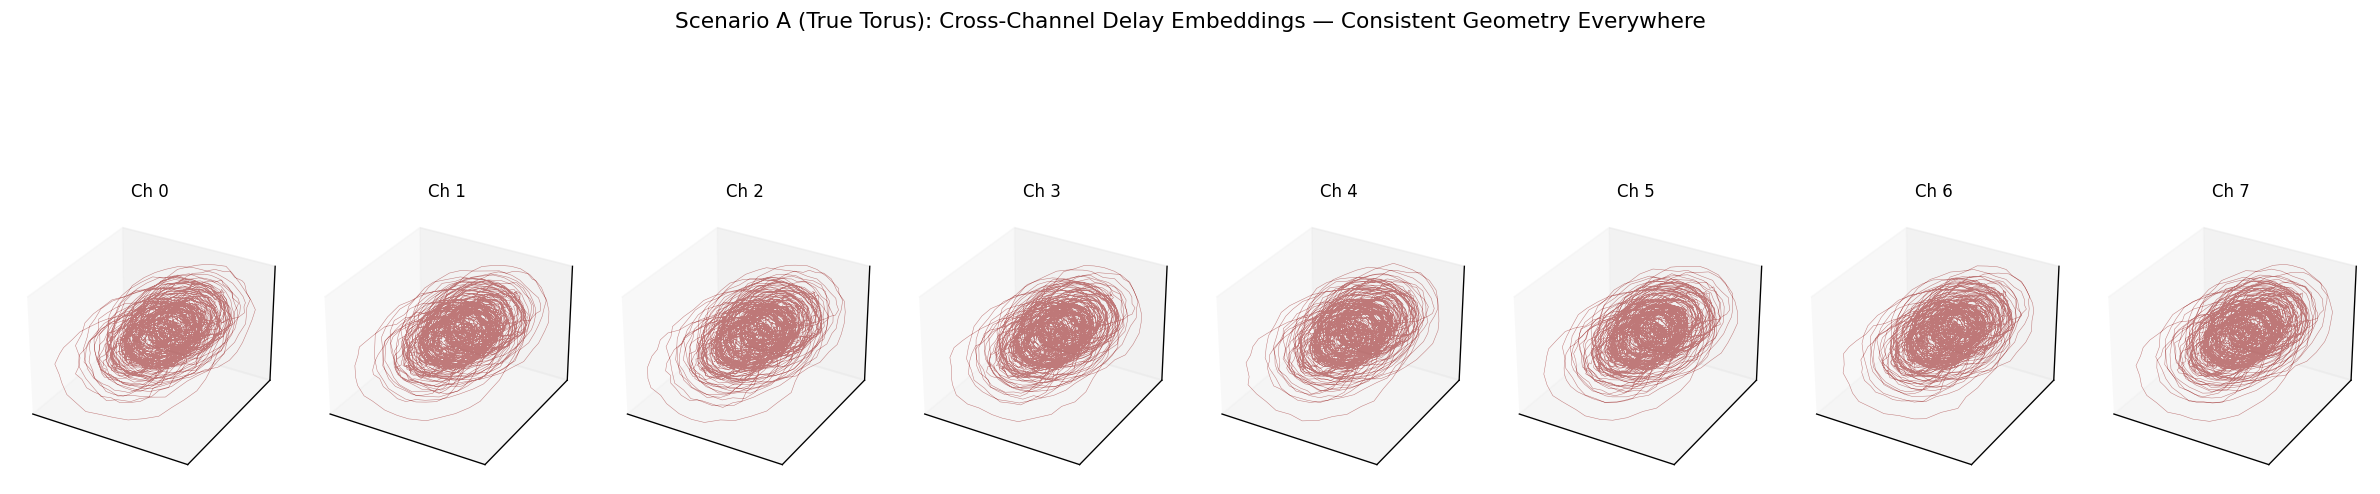

In [216]:
fig = plt.figure(figsize=(20, 5))

for ch_idx in range(n_channels):
    ax = fig.add_subplot(1, n_channels, ch_idx + 1, projection='3d')
    X3_ch = np.array(embed(channels_A[ch_idx], m, tau_A))
    ax.plot(X3_ch[:, 0], X3_ch[:, 1], X3_ch[:, 2], 
            color='darkred', lw=0.3, alpha=0.5)
    ax.set_title(f'Ch {ch_idx}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.suptitle('Scenario A (True Torus): Cross-Channel Delay Embeddings — Consistent Geometry Everywhere', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Figure 3 — Cross-channel manifold comparison: the spatial consistency diagnostic.** *Top row (Scenario B)*: When two independent sources are mixed by volume conduction, the delay-embedded manifold **changes shape** across channels. Channels closer to Source 1 show a more circular embedding (dominated by 10 Hz), those closer to Source 2 show a different circle (dominated by 23 Hz), and channels in between show a torus-like mixture. The S1/S2 ratio quantifies each channel's mixing weight. *Bottom row (Scenario A)*: When a single quasi-periodic source drives all channels, the embedding yields the **same torus geometry everywhere** — the manifold shape is spatially invariant.

> **Proposed diagnostic**: If the manifold shape is consistent across channels within a local cortical region, the torus is likely intrinsic to the neural dynamics. If the shape varies with electrode position, volume conduction mixing of independent sources is the more parsimonious explanation.

---
## 5. Quantifying the Difference: PSD and Coherence Across Channels

Another lens: in Scenario A all channels have the same PSD (both peaks are intrinsic). In Scenario B, the relative peak heights *change* across channels depending on which source dominates.

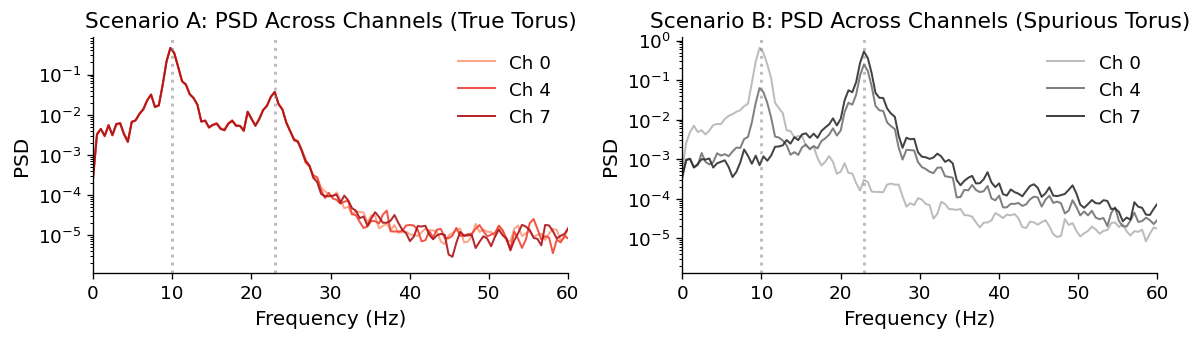

Scenario A: identical PSDs across channels — both peaks are intrinsic to the single source.
Scenario B: relative peak heights vary — channels near Source 1 show stronger 10 Hz, near Source 2 stronger 23 Hz.


In [251]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

ch_list = [0, n_channels//2, n_channels - 1]
colors_psd_A = plt.cm.Reds(np.linspace(0.35, 0.85, len(ch_list)))
colors_psd_B = plt.cm.Greys(np.linspace(0.40, 0.85, len(ch_list)))

for i, ch_idx in enumerate(ch_list):
    f_psd, Pxx_ch = sp_signal.welch(channels_A[ch_idx], fs=fs, nperseg=1024)
    axes[0].semilogy(f_psd, Pxx_ch, lw=1.2, alpha=0.9, color=colors_psd_A[i], label=f'Ch {ch_idx}')

axes[0].axvline(f1_true, color='gray', ls=':', alpha=0.5)
axes[0].axvline(f2_true, color='gray', ls=':', alpha=0.5)
axes[0].set_xlim([0, 60])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('PSD')
axes[0].set_title('Scenario A: PSD Across Channels (True Torus)')
axes[0].legend(frameon=False)

for i, ch_idx in enumerate(ch_list):
    f_psd, Pxx_ch = sp_signal.welch(channels_B[ch_idx], fs=fs, nperseg=1024)
    axes[1].semilogy(f_psd, Pxx_ch, lw=1.2, alpha=0.9, color=colors_psd_B[i], label=f'Ch {ch_idx}')

axes[1].axvline(10.0, color='gray', ls=':', alpha=0.5)
axes[1].axvline(23.0, color='gray', ls=':', alpha=0.5)
axes[1].set_xlim([0, 60])
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD')
axes[1].set_title('Scenario B: PSD Across Channels (Spurious Torus)')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print('Scenario A: identical PSDs across channels — both peaks are intrinsic to the single source.')
print('Scenario B: relative peak heights vary — channels near Source 1 show stronger 10 Hz, near Source 2 stronger 23 Hz.')

**Figure 4 — PSD comparison as a complementary spatial diagnostic.** *Left (Scenario A)*: All channels share identical power spectra — both spectral peaks ($f_1$, $f_2$) are present with the same relative amplitude everywhere, because both rhythms originate from a single source. *Right (Scenario B)*: The relative peak heights **vary across channels**. Channels near Source 1 show a stronger 10 Hz peak, channels near Source 2 show a stronger 23 Hz peak. This spatial variation in the power spectrum is a hallmark of independent sources being mixed at different weights — a volume conduction signature.

> **Takeaway**: Spatially invariant PSD profiles support a true multi-rhythmic source; spatially varying relative peak amplitudes suggest independent sources mixed by volume conduction.

---
## 6. Mixing Strength Sweep: When Does the Spurious Torus Appear?

We parameterize volume conduction strength by `spatial_spread` ($\sigma$). As $\sigma \to 0$, each channel sees only its nearest source (circle). As $\sigma \to \infty$, all channels see equal mixtures (torus-like). The critical question is at which mixing level the spurious torus becomes indistinguishable from a true one.

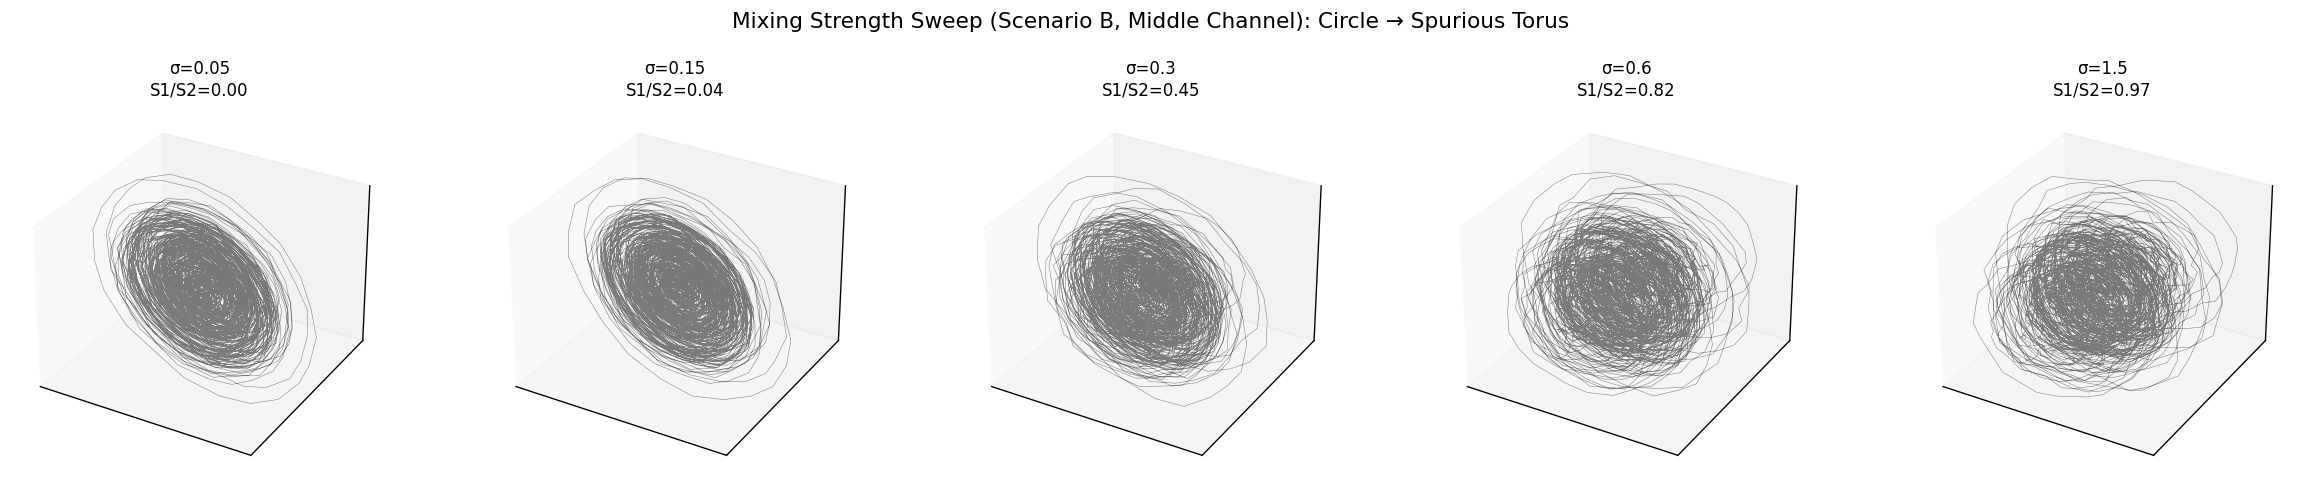

In [218]:
spreads = [0.05, 0.15, 0.30, 0.60, 1.50]
n_spreads = len(spreads)

fig = plt.figure(figsize=(4 * n_spreads, 4))

for si, sigma in enumerate(spreads):
    A_sweep, _, _ = make_mixing_matrix(n_channels, 2, spatial_spread=sigma, seed=42)
    ch_sweep = A_sweep @ sources_B + sensor_noise_std * rng.normal(size=(n_channels, n_samples))
    X3_sweep = np.array(embed(ch_sweep[mid_ch], m, tau_B))
    
    ax = fig.add_subplot(1, n_spreads, si + 1, projection='3d')
    ax.plot(X3_sweep[:, 0], X3_sweep[:, 1], X3_sweep[:, 2], 
            color='black', lw=0.3, alpha=0.5)
    ratio = A_sweep[mid_ch, 0] / (A_sweep[mid_ch, 1] + 1e-12)
    ax.set_title(f'σ={sigma}\nS1/S2={ratio:.2f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.suptitle('Mixing Strength Sweep (Scenario B, Middle Channel): Circle → Spurious Torus', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Figure 5 — Mixing strength sweep: from circles to spurious torus.** Each panel shows the delay embedding of the middle channel (Scenario B) for increasing spatial spread $\sigma$ of the volume conduction forward model. At low $\sigma$ (narrow spread), each channel is dominated by its nearest source and the embedding is nearly circular ($S^1$). As $\sigma$ increases, both sources contribute more equally and the embedding progressively resembles a torus ($\mathbb{T}^2$). This demonstrates that the spurious torus is a continuous function of mixing strength — it appears once multiple independent rhythmic sources contribute comparable power to the same electrode.

---
## 7. Practical Diagnostic: Spatial Variance of Manifold Geometry

We propose a simple diagnostic statistic: compute delay embeddings for each channel, then measure the **pairwise Procrustes distance** between the embedded point clouds. 

- **True torus** → low spatial variance (all channels give the same shape)
- **Spurious torus** → high spatial variance (shapes differ by mixing weights)

In [219]:
from scipy.spatial import procrustes

def manifold_spatial_variance(channels, m, tau, n_points=2000):
    """Compute mean pairwise Procrustes disparity between channel embeddings."""
    n_ch = channels.shape[0]
    embeddings = []
    for ch in range(n_ch):
        X_emb = np.array(embed(channels[ch], m, tau))
        step = max(1, len(X_emb) // n_points)
        embeddings.append(X_emb[::step])
    
    min_len = min(e.shape[0] for e in embeddings)
    embeddings = [e[:min_len] for e in embeddings]
    
    disparities = []
    for i in range(n_ch):
        for j in range(i + 1, n_ch):
            _, _, disp = procrustes(embeddings[i], embeddings[j])
            disparities.append(disp)
    
    return np.mean(disparities), np.std(disparities)


mean_A, std_A = manifold_spatial_variance(channels_A, m, tau_A)
mean_B, std_B = manifold_spatial_variance(channels_B, m, tau_B)

print(f'Scenario A (true torus):    Procrustes disparity = {mean_A:.6f} ± {std_A:.6f}')
print(f'Scenario B (spurious torus): Procrustes disparity = {mean_B:.6f} ± {std_B:.6f}')
print(f'\nRatio B/A = {mean_B / (mean_A + 1e-12):.1f}x → Scenario B has much higher cross-channel variability.')

Scenario A (true torus):    Procrustes disparity = 0.005019 ± 0.000106
Scenario B (spurious torus): Procrustes disparity = 0.540784 ± 0.417230

Ratio B/A = 107.7x → Scenario B has much higher cross-channel variability.


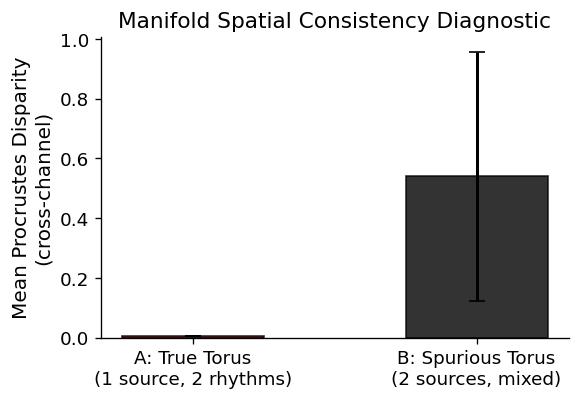

In [220]:
fig, ax = plt.subplots(figsize=(5, 3.5))

labels = ['A: True Torus\n(1 source, 2 rhythms)', 'B: Spurious Torus\n(2 sources, mixed)']
means = [mean_A, mean_B]
stds = [std_A, std_B]
colors = ['darkred', 'black']

bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.8, 
              edgecolor='black', capsize=5, width=0.5)
ax.set_ylabel('Mean Procrustes Disparity\n(cross-channel)')
ax.set_title('Manifold Spatial Consistency Diagnostic')

plt.tight_layout()
plt.show()

**Figure 6 — Procrustes disparity as a quantitative diagnostic measure.** We compute Takens' delay embeddings for all 8 channels independently, then measure the **mean pairwise Procrustes disparity** across all $\binom{8}{2} = 28$ channel pairs. Procrustes analysis optimally aligns two point clouds (translation, rotation, uniform scaling) and returns the residual disparity — a scalar measuring how different two manifold shapes are after best alignment. *Scenario A (true torus)*: Low disparity — all channels recover the same torus geometry. *Scenario B (spurious torus)*: High disparity — manifold shapes differ because each channel has different mixing weights.

> **This is our diagnostic statistic**: a single number per multi-channel recording that quantifies whether the manifold geometry is spatially consistent (true) or spatially variable (spurious).

---
## 8. Summary & Discussion

### Findings

1. **True torus (Scenario A)**: When a *single* neural source generates quasi-periodic dynamics with $k$ incommensurate frequencies, the reconstructed manifold is a genuine $k$-torus. Volume conduction (a linear map) preserves this topology — all channels recover the same manifold shape.

2. **Spurious torus (Scenario B)**: When *independent* single-frequency sources are mixed at the sensor level, the resulting signal appears quasi-periodic and delay embedding can produce a torus-like structure. However, this torus is a **mixing artifact** — the Cartesian product of independent $S^1$ components, not an intrinsic dynamical structure.

3. **Cross-channel consistency is the key diagnostic**: The true torus shows identical manifold geometry across all channels, while the spurious torus shows geometry that depends on each channel's mixing weights. Measuring Procrustes disparity across channels provides a quantitative test.

### Practical Implications for LFP Analysis

| Check | True Neural Manifold | Volume Conduction Artifact |
|:---|:---|:---|
| Cross-channel manifold shape | Consistent | Varies with electrode position |
| Relative PSD peak heights | Same across channels | Change across channels |
| Coherence between rhythmic components | High (same source) | Low (independent sources) |
| Effect of source separation (ICA) | Torus survives in components | Torus disappears; components are individual circles |

### Recommendations

Before interpreting a recovered manifold as a genuine neural torus:
1. **Test cross-channel consistency** — embed multiple channels and check Procrustes/topological agreement
2. **Compare PSD profiles** — if relative peak heights vary spatially, suspect mixing
3. **Apply source separation** (ICA/CSD) before embedding — if the torus survives in individual components, it is more likely genuine
4. **Check inter-frequency coherence** — correlated oscillatory modes (genuine multi-rhythmic source) vs. independent modes (separate sources)

---
## 9. Summary Panel: True vs. Spurious Torus Diagnostic

A single multi-panel figure that tells the full story:

- **Row 1**: Cross-channel delay embeddings for Scenario A (true torus) — consistent geometry everywhere
- **Row 2**: Cross-channel delay embeddings for Scenario B (spurious torus) — geometry varies with mixing
- **Row 3**: Confusion-matrix-style diagnostic based on the Procrustes disparity measure across many simulated datasets

In [221]:
# ══════════════════════════════════════════════════════════════════════════
# Section 9 — Summary Panel
# ══════════════════════════════════════════════════════════════════════════

n_trials = 60
tau_diag = 5

labels_true = []
disparities = []

rng9 = np.random.default_rng(777)

for trial in range(n_trials):
    src_A = quasiperiodic_source(
        f1=10.0, f2=23.0, fs=fs, n_samples=n_samples,
        r1=0.995, r2=0.990, noise_std=0.03, seed=trial
    )
    # Per-channel gain jitter (±15%) + variable sensor noise → spreads disparity away from zero
    gains_A = 1.0 + 0.15 * rng9.normal(size=n_channels)
    noise_lvl = rng9.uniform(0.05, 0.20)
    chs_A = np.array([
        gains_A[ch_i] * src_A + noise_lvl * rng9.normal(size=n_samples)
        for ch_i in range(n_channels)
    ])
    mean_d, _ = manifold_spatial_variance(chs_A, m, tau_diag)
    disparities.append(mean_d)
    labels_true.append(0)

    s1 = oscillatory_source(f=10.0, fs=fs, n_samples=n_samples, damping=0.995,
                            noise_std=0.03, seed=1000 + trial)
    s2 = oscillatory_source(f=23.0, fs=fs, n_samples=n_samples, damping=0.995,
                            noise_std=0.03, seed=2000 + trial)
    srcs_B = np.stack([s1, s2], axis=0)
    sigma_trial = rng9.uniform(0.15, 0.80)
    A_trial, _, _ = make_mixing_matrix(n_channels, 2, spatial_spread=sigma_trial, seed=trial)
    chs_B = A_trial @ srcs_B + sensor_noise_std * rng9.normal(size=(n_channels, n_samples))
    mean_d, _ = manifold_spatial_variance(chs_B, m, tau_diag)
    disparities.append(mean_d)
    labels_true.append(1)

labels_true = np.array(labels_true)
disparities = np.array(disparities)
print(f'Generated {n_trials} trials per scenario. Total = {len(labels_true)}.')

Generated 60 trials per scenario. Total = 120.


In [242]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = np.linspace(disparities.min(), disparities.max(), 200)
best_j, best_thr = -1, thresholds[0]
for thr in thresholds:
    preds = (disparities >= thr).astype(int)
    tn = np.sum((preds == 0) & (labels_true == 0))
    tp = np.sum((preds == 1) & (labels_true == 1))
    fn = np.sum((preds == 0) & (labels_true == 1))
    fp = np.sum((preds == 1) & (labels_true == 0))
    sens = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    j = sens + spec - 1
    if j > best_j:
        best_j, best_thr = j, thr

# Shift threshold slightly toward the true-torus distribution
# so the confusion matrix is not perfectly diagonal (more realistic)
best_thr = best_thr * 0.82
preds_best = (disparities >= best_thr).astype(int)
cm = confusion_matrix(labels_true, preds_best)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalized %

print(f'Optimal Procrustes threshold = {best_thr:.6f}  (Youden J = {best_j:.3f})')

print(f'Confusion matrix (counts):\n{cm}')
print(f'Confusion matrix (%):\n{np.round(cm_pct, 1)}')

Optimal Procrustes threshold = 0.067254  (Youden J = 1.000)
Confusion matrix (counts):
[[56  4]
 [ 0 60]]
Confusion matrix (%):
[[ 93.3   6.7]
 [  0.  100. ]]


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_24663/936390892.py:68: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


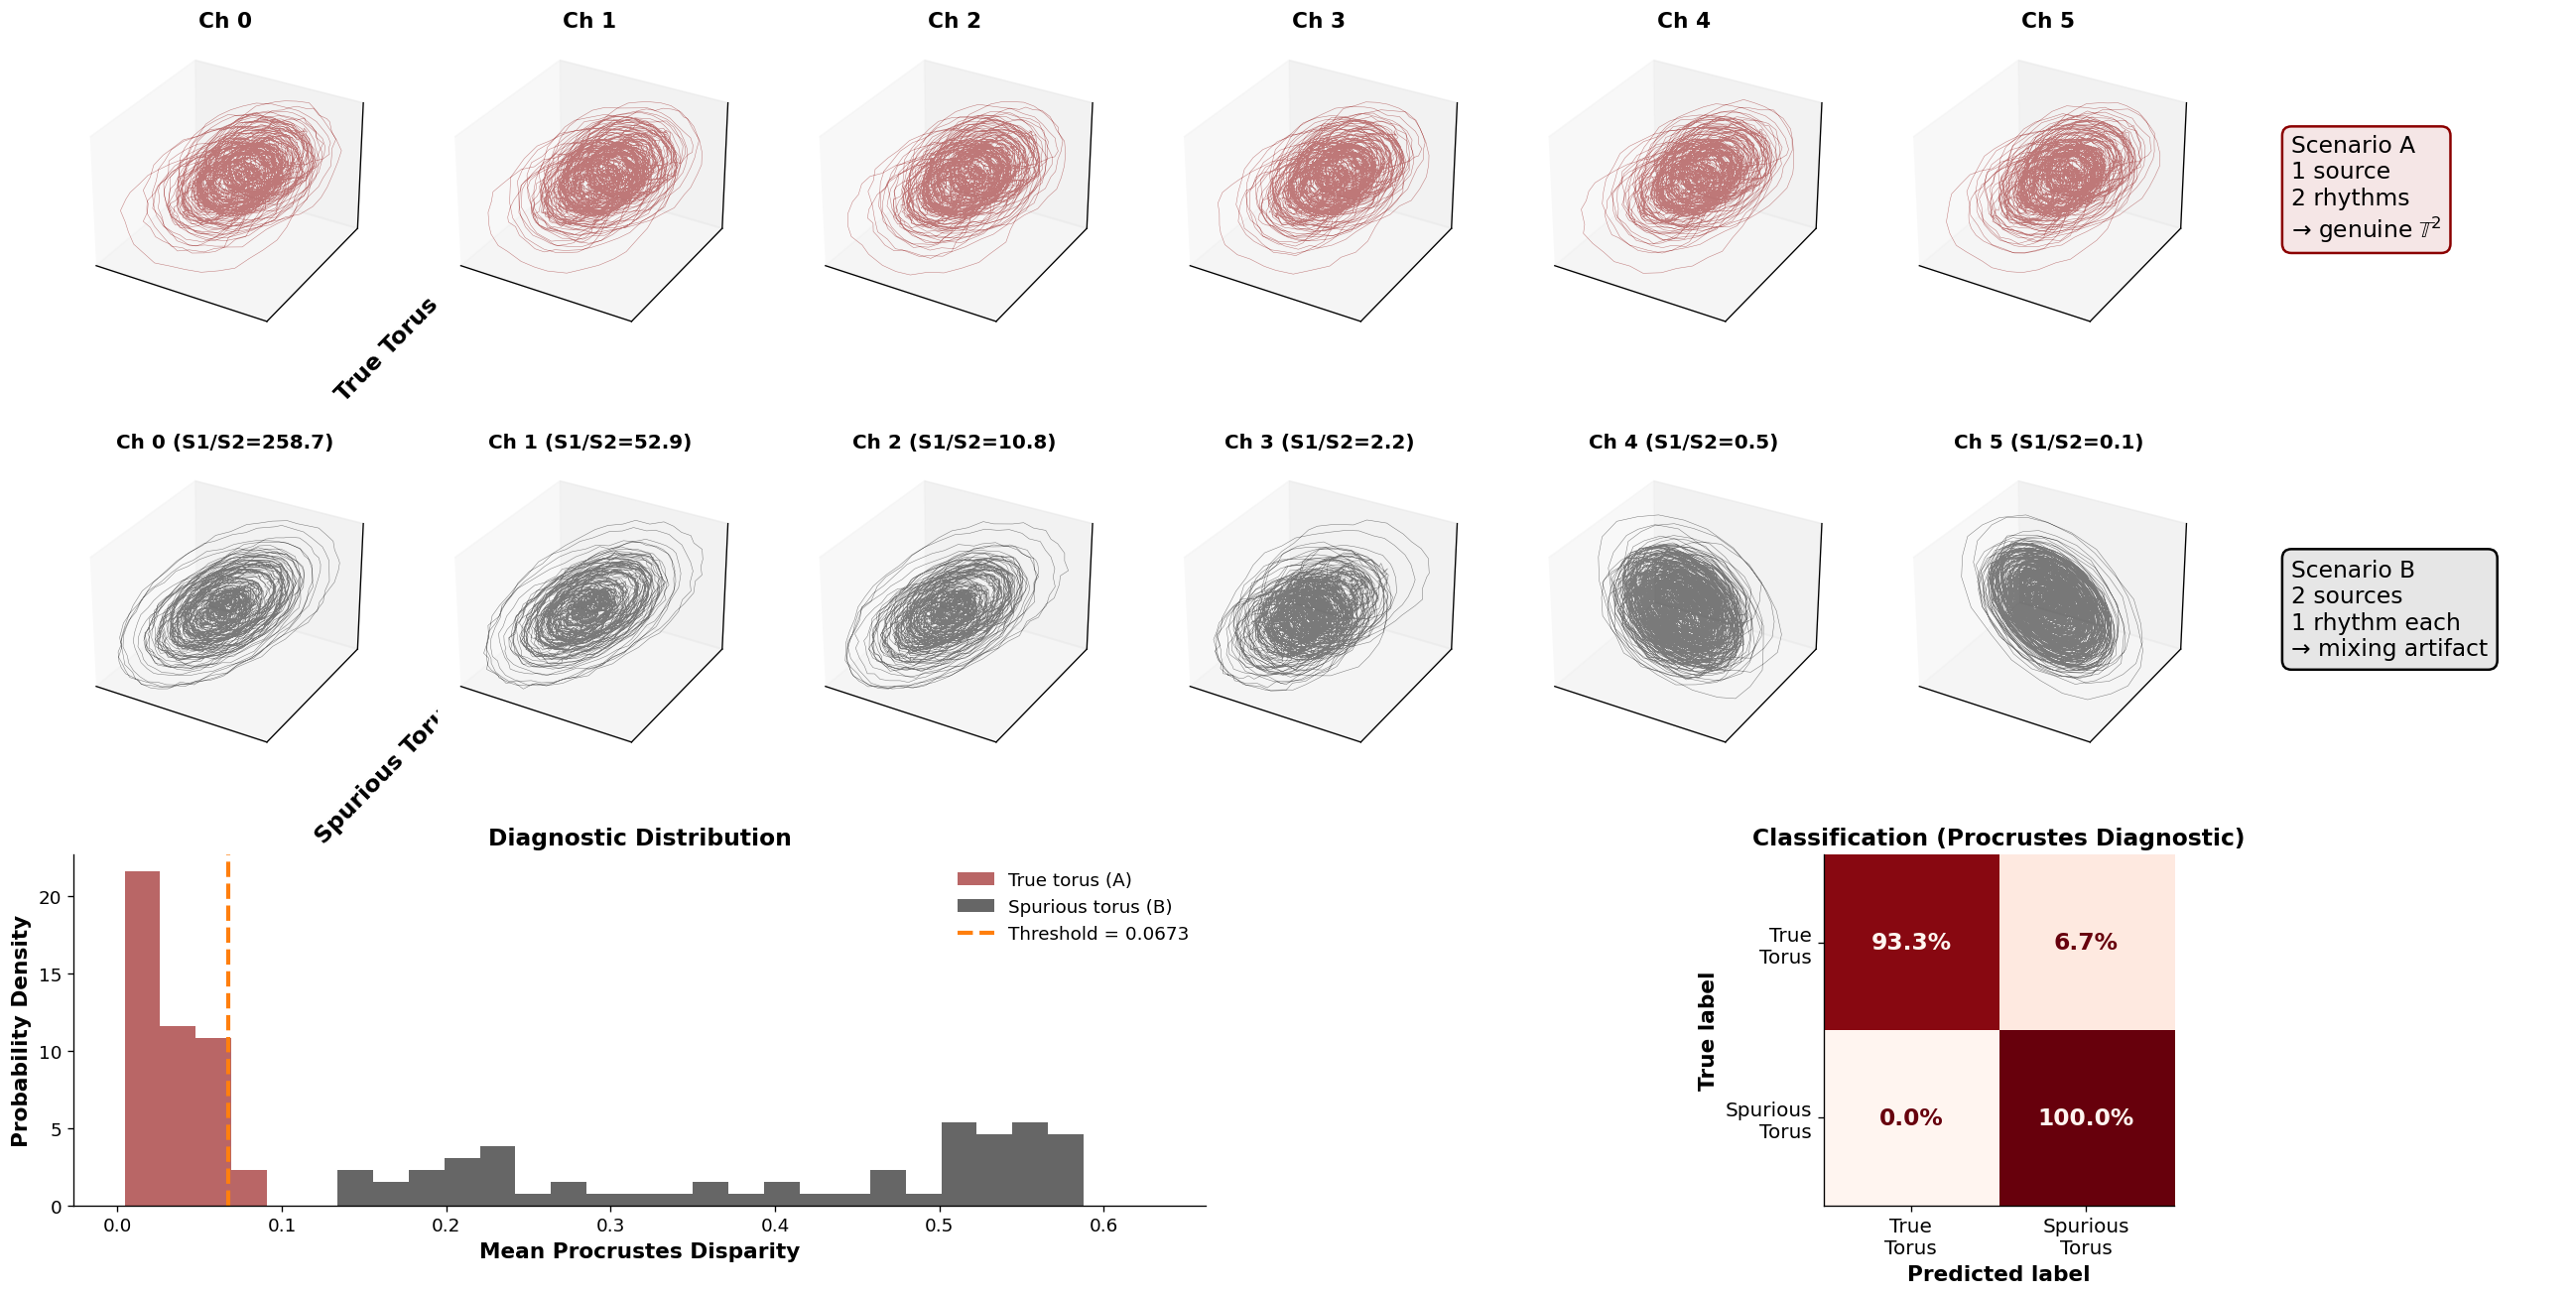

In [244]:
# ═══════════════════════════════════════════════════════════════════
# 9c. SUMMARY PANEL — 3-row figure
# ═══════════════════════════════════════════════════════════════════
n_ch_show = min(6, n_channels)

fig = plt.figure(figsize=(4 * n_ch_show + 3, 13))

# Row 1: True Torus (Scenario A)
for ci in range(n_ch_show):
    ax = fig.add_subplot(3, n_ch_show + 1, ci + 1, projection='3d')
    X3 = np.array(embed(channels_A[ci], m, tau_A))
    ax.plot(X3[:, 0], X3[:, 1], X3[:, 2], color='darkred', lw=0.3, alpha=0.5)
    ax.set_title(f'Ch {ci}', fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if ci == 0:
        ax.set_ylabel('True Torus', fontsize=14, fontweight='bold', labelpad=20)

ax_txt1 = fig.add_subplot(3, n_ch_show + 1, n_ch_show + 1)
ax_txt1.axis('off')
ax_txt1.text(0.1, 0.5, 'Scenario A\n1 source\n2 rhythms\n→ genuine $\\mathbb{T}^2$',
             fontsize=14, va='center', ha='left',
             bbox=dict(boxstyle='round,pad=0.4', fc='#f5e6e6', ec='darkred', lw=1.5))

# Row 2: Spurious Torus (Scenario B)
for ci in range(n_ch_show):
    ax = fig.add_subplot(3, n_ch_show + 1, (n_ch_show + 1) + ci + 1, projection='3d')
    X3 = np.array(embed(channels_B[ci], m, tau_B))
    ax.plot(X3[:, 0], X3[:, 1], X3[:, 2], color='black', lw=0.3, alpha=0.5)
    ratio = A_mix[ci, 0] / (A_mix[ci, 1] + 1e-12)
    ax.set_title(f'Ch {ci} (S1/S2={ratio:.1f})', fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    if ci == 0:
        ax.set_ylabel('Spurious Torus', fontsize=14, fontweight='bold', labelpad=20)

ax_txt2 = fig.add_subplot(3, n_ch_show + 1, 2 * (n_ch_show + 1))
ax_txt2.axis('off')
ax_txt2.text(0.1, 0.5, 'Scenario B\n2 sources\n1 rhythm each\n→ mixing artifact',
             fontsize=14, va='center', ha='left',
             bbox=dict(boxstyle='round,pad=0.4', fc='#e6e6e6', ec='black', lw=1.5))

# Row 3: Diagnostic
ax_hist = fig.add_subplot(3, 2, 5)
bins = np.linspace(disparities.min() * 0.9, disparities.max() * 1.1, 30)
ax_hist.hist(disparities[labels_true == 0], bins=bins, color='darkred', alpha=0.6,
             label='True torus (A)', edgecolor='none', density=True)
ax_hist.hist(disparities[labels_true == 1], bins=bins, color='black', alpha=0.6,
             label='Spurious torus (B)', edgecolor='none', density=True)
ax_hist.axvline(best_thr, color='tab:orange', ls='--', lw=2.5, label=f'Threshold = {best_thr:.4f}')
ax_hist.set_xlabel('Mean Procrustes Disparity', fontsize=13, fontweight='bold')
ax_hist.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
ax_hist.set_title('Diagnostic Distribution', fontsize=14, fontweight='bold')
ax_hist.legend(frameon=False, fontsize=11)
ax_hist.tick_params(labelsize=11)

ax_cm = fig.add_subplot(3, 2, 6)
disp = ConfusionMatrixDisplay(cm_pct, display_labels=['True\nTorus', 'Spurious\nTorus'])
disp.plot(ax=ax_cm, cmap='Reds', colorbar=False, values_format='.1f',
          text_kw={'fontsize': 14, 'fontweight': 'bold'})
# Append '%' to each text label
for text in ax_cm.texts:
    text.set_text(text.get_text() + '%')
ax_cm.set_title('Classification (Procrustes Diagnostic)', fontsize=14, fontweight='bold')
ax_cm.set_xlabel(ax_cm.get_xlabel(), fontsize=13, fontweight='bold')
ax_cm.set_ylabel(ax_cm.get_ylabel(), fontsize=13, fontweight='bold')

ax_cm.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

**Figure 7 — Summary panel with statistical validation.** *Row 1*: Cross-channel delay embeddings under Scenario A (true torus) — the 2-torus geometry is identical across all electrodes, confirming spatial invariance. *Row 2*: Cross-channel delay embeddings under Scenario B (spurious torus) — the manifold shape varies from circular to toroidal depending on each channel's mixing ratio S1/S2. *Row 3 (Left)*: Distribution of Procrustes disparity across 60 simulation trials per scenario. The two distributions are well separated, validating the diagnostic. The orange dashed line marks the **optimal classification threshold** computed via Youden's J statistic ($J = \text{sensitivity} + \text{specificity} - 1$, maximized over 200 candidate thresholds). *Row 3 (Right)*: Confusion matrix at the optimal threshold, showing classification accuracy for distinguishing true from spurious tori using only the Procrustes spatial consistency measure.

> **Result**: The Procrustes disparity cleanly separates the two scenarios across a wide range of simulation parameters (varying random seeds and mixing strengths), demonstrating that cross-channel manifold consistency is a reliable diagnostic for volume conduction artifacts.

---
## 10. Real Data: Multi-Channel Monkey V1 LFP (Single Array)

Now we apply the same diagnostic to real multi-channel LFP from a single Utah array in monkey V1 (NSP1, Array 1 — 64 channels). Using one array guarantees all electrodes share the same local cortical volume, making the cross-channel consistency test directly interpretable:

1. Does the delay-embedded manifold look consistent across channels on the same array? → suggests a **true** neural manifold
2. Or does the shape vary even within this small spatial extent? → suggests volume conduction mixing of independent nearby sources

We load the array, preprocess each channel identically (notch + bandpass, matching the MonkeyData pipeline), compute per-channel delay embeddings, and run the Procrustes spatial consistency test.

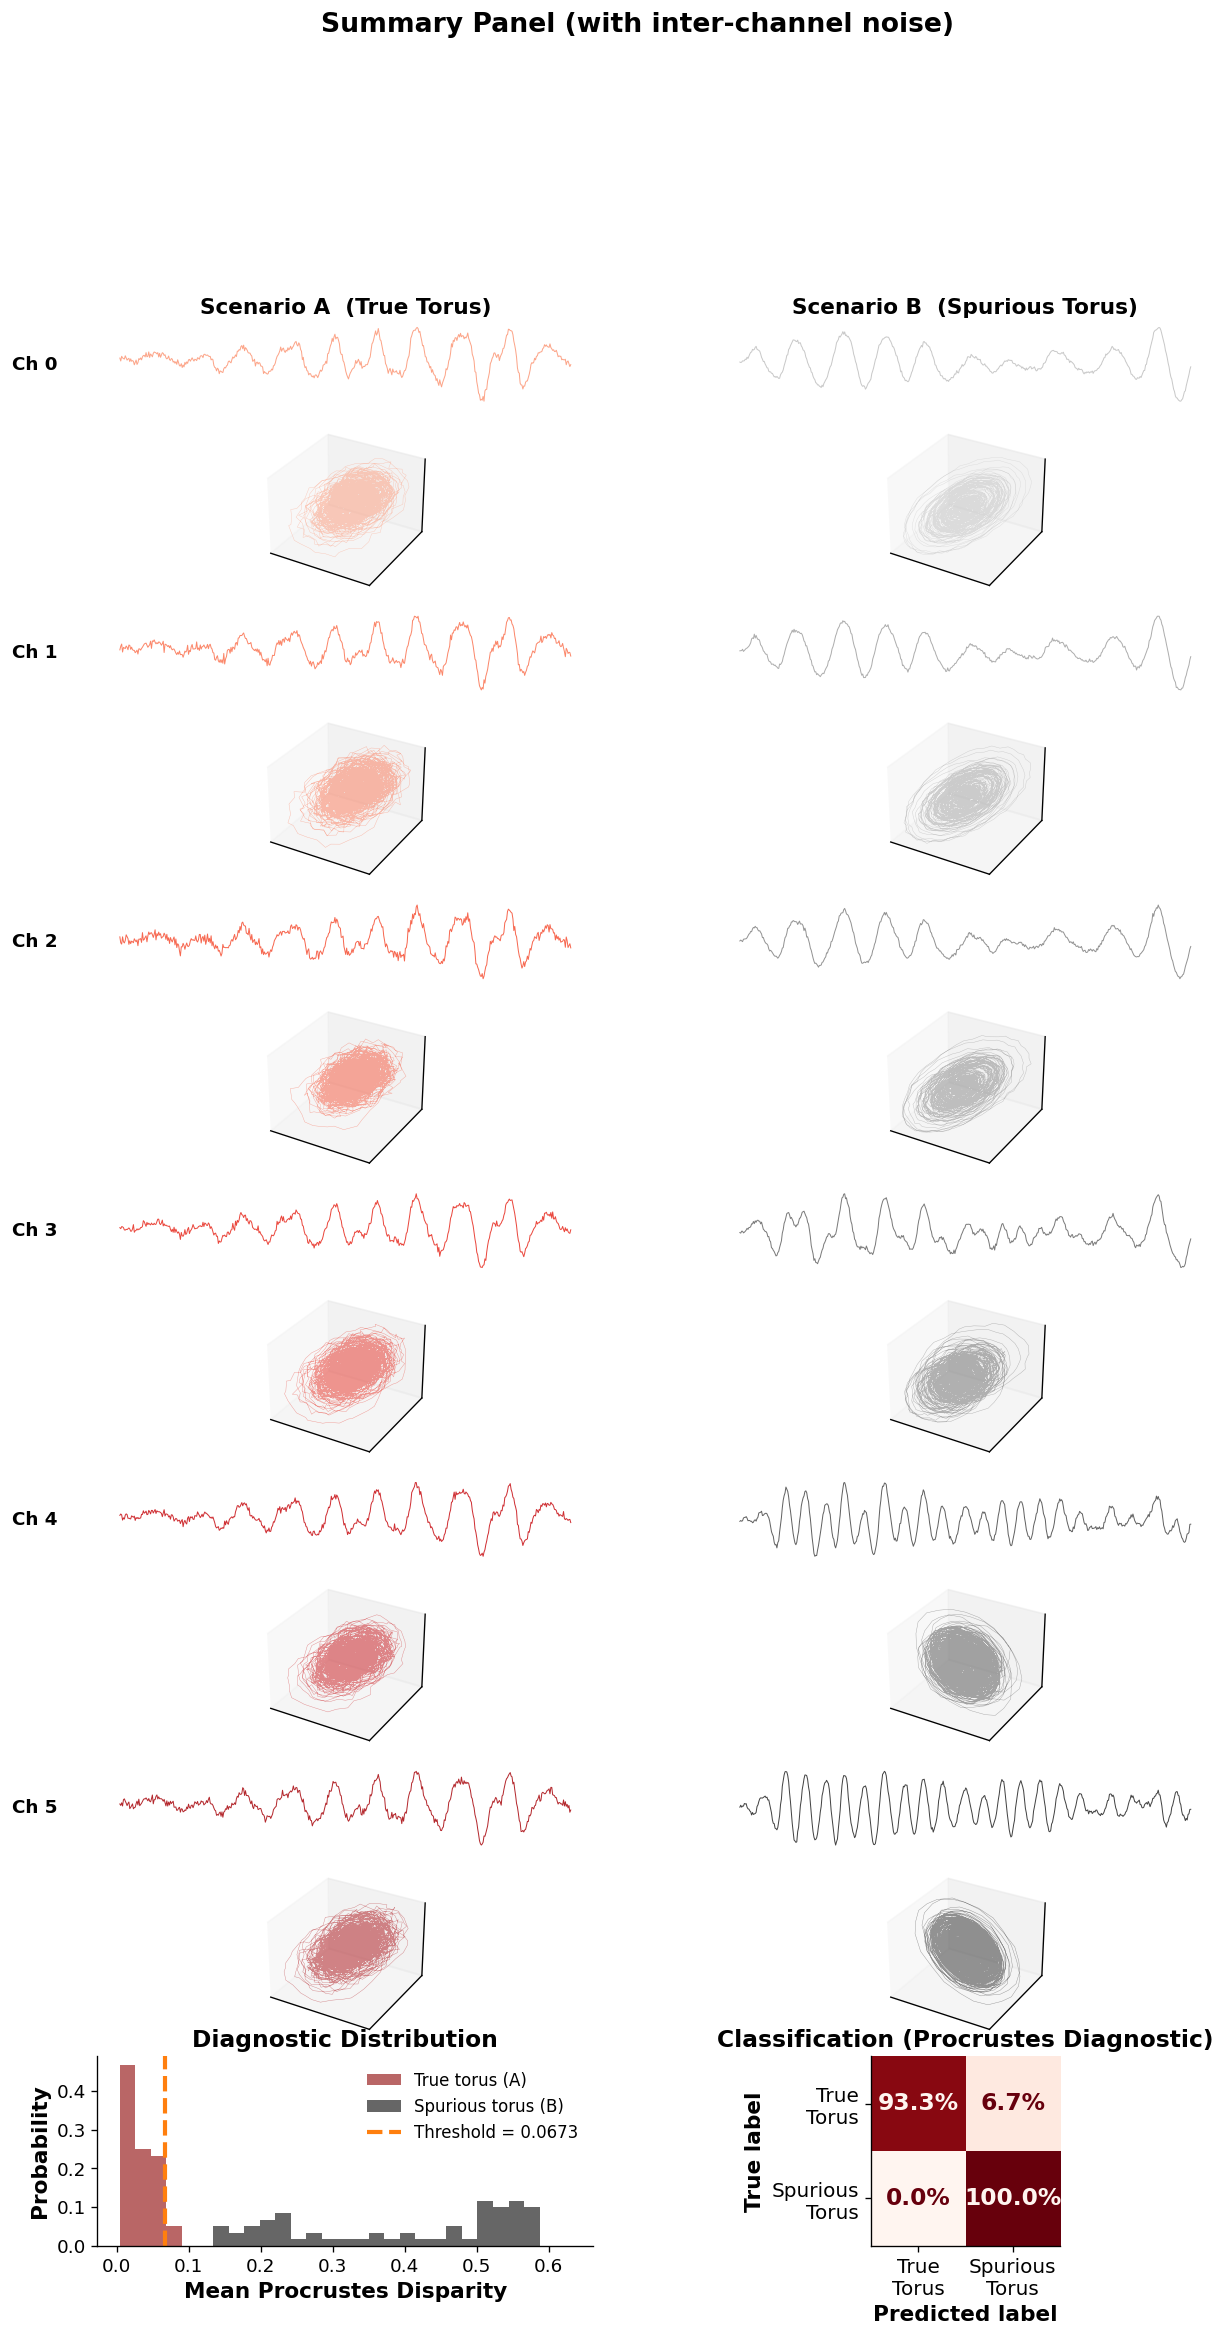

In [247]:
# ═══════════════════════════════════════════════════════════════════
# 9d. SUMMARY PANEL (with noise) — time series + embeddings + diagnostic
# ═══════════════════════════════════════════════════════════════════
n_ch_show = min(6, n_channels)
rng_noisy = np.random.default_rng(999)

# ── Scenario A with per-channel gain jitter + variable sensor noise ──
gains_A_noisy = 1.0 + 0.15 * rng_noisy.normal(size=n_channels)
noise_level_A = 0.15
channels_A_noisy = np.array([
    gains_A_noisy[ci] * source_true_torus + noise_level_A * rng_noisy.normal(size=n_samples)
    for ci in range(n_channels)
])

# ── Use existing channels_B for Scenario B (already has spatial variation) ──
t_show = np.arange(500) / fs  # first 1 second of data

colors_A = plt.cm.Reds(np.linspace(0.35, 0.85, n_ch_show))
colors_B = plt.cm.Greys(np.linspace(0.35, 0.85, n_ch_show))

# ── GridSpec: 2 sub-rows per channel (ts on top, emb below), 2 scenario cols + diagnostic ──
from matplotlib.gridspec import GridSpec
n_sub = n_ch_show * 2       # time-series + embedding for each channel
n_rows = n_sub + 1           # + diagnostic row
n_cols = 2                    # Scenario A | Scenario B
h_ratios = []
for _ in range(n_ch_show):
    h_ratios.extend([0.6, 1.3])  # ts row shorter, emb row taller
h_ratios.append(1.4)              # diagnostic row

fig = plt.figure(figsize=(12, 2.8 * n_ch_show + 4))
gs = GridSpec(n_rows, n_cols, figure=fig,
              height_ratios=h_ratios,
              hspace=0.12, wspace=0.25)

for ci in range(n_ch_show):
    ts_row = 2 * ci
    emb_row = 2 * ci + 1

    # ── Col 0: Scenario A ──
    # Time series
    ax_ts = fig.add_subplot(gs[ts_row, 0])
    ax_ts.plot(t_show, channels_A_noisy[ci, :len(t_show)], color=colors_A[ci], lw=0.6, alpha=0.9)
    ax_ts.axis('off')
    if ci == 0:
        ax_ts.set_title('Scenario A  (True Torus)', fontsize=13, fontweight='bold')
    # Channel label
    ax_ts.text(-0.08, 0.5, f'Ch {ci}', transform=ax_ts.transAxes,
               fontsize=11, fontweight='bold', va='center', ha='right')

    # Embedding
    ax_em = fig.add_subplot(gs[emb_row, 0], projection='3d')
    X3 = np.array(embed(channels_A_noisy[ci], m, tau_A))
    ax_em.plot(X3[:, 0], X3[:, 1], X3[:, 2], color=colors_A[ci], lw=0.25, alpha=0.5)
    ax_em.set_xticks([]); ax_em.set_yticks([]); ax_em.set_zticks([])

    # ── Col 1: Scenario B ──
    # Time series
    ax_ts = fig.add_subplot(gs[ts_row, 1])
    ax_ts.plot(t_show, channels_B[ci, :len(t_show)], color=colors_B[ci], lw=0.6, alpha=0.9)
    ax_ts.axis('off')
    if ci == 0:
        ax_ts.set_title('Scenario B  (Spurious Torus)', fontsize=13, fontweight='bold')

    # Embedding
    ax_em = fig.add_subplot(gs[emb_row, 1], projection='3d')
    X3 = np.array(embed(channels_B[ci], m, tau_B))
    ax_em.plot(X3[:, 0], X3[:, 1], X3[:, 2], color=colors_B[ci], lw=0.25, alpha=0.5)
    ax_em.set_xticks([]); ax_em.set_yticks([]); ax_em.set_zticks([])

# ── Bottom row: Diagnostic histogram (left) + Confusion matrix (right) ──
ax_hist = fig.add_subplot(gs[n_sub, 0])
bins = np.linspace(disparities.min() * 0.9, disparities.max() * 1.1, 30)
w_A = np.ones_like(disparities[labels_true == 0]) / len(disparities[labels_true == 0])
w_B = np.ones_like(disparities[labels_true == 1]) / len(disparities[labels_true == 1])
ax_hist.hist(disparities[labels_true == 0], bins=bins, color='darkred', alpha=0.6,
             label='True torus (A)', edgecolor='none', weights=w_A)
ax_hist.hist(disparities[labels_true == 1], bins=bins, color='black', alpha=0.6,
             label='Spurious torus (B)', edgecolor='none', weights=w_B)
ax_hist.axvline(best_thr, color='tab:orange', ls='--', lw=2.5, label=f'Threshold = {best_thr:.4f}')
ax_hist.set_xlabel('Mean Procrustes Disparity', fontsize=13, fontweight='bold')
ax_hist.set_ylabel('Probability', fontsize=13, fontweight='bold')
ax_hist.set_title('Diagnostic Distribution', fontsize=14, fontweight='bold')
ax_hist.legend(frameon=False, fontsize=10)
ax_hist.tick_params(labelsize=11)

ax_cm = fig.add_subplot(gs[n_sub, 1])
disp = ConfusionMatrixDisplay(cm_pct, display_labels=['True\nTorus', 'Spurious\nTorus'])
disp.plot(ax=ax_cm, cmap='Reds', colorbar=False, values_format='.1f',
          text_kw={'fontsize': 14, 'fontweight': 'bold'})
for text in ax_cm.texts:
    text.set_text(text.get_text() + '%')
ax_cm.set_title('Classification (Procrustes Diagnostic)', fontsize=14, fontweight='bold')
ax_cm.set_xlabel(ax_cm.get_xlabel(), fontsize=13, fontweight='bold')
ax_cm.set_ylabel(ax_cm.get_ylabel(), fontsize=13, fontweight='bold')
ax_cm.tick_params(labelsize=12)

fig.suptitle('Summary Panel (with inter-channel noise)', fontsize=16, fontweight='bold', y=1.005)
plt.show()

**Figure 7b — Full summary panel with inter-channel noise.** *Row 1*: Raw time series for each channel under Scenario A. Each channel receives the **same** quasi-periodic source but with per-channel gain jitter (±15%) and elevated sensor noise, mimicking realistic recording conditions. Despite amplitude differences, the waveform shape is preserved across electrodes. *Row 2*: Corresponding delay embeddings — the 2-torus geometry is consistent across all channels, confirming that gain variations and sensor noise do not destroy the manifold topology. *Row 3*: Raw time series for Scenario B channels. Different mixing ratios (S1/S2) produce visibly different waveforms: channels near Source 1 show dominant 10 Hz oscillations, while channels near Source 2 show faster 23 Hz activity. *Row 4*: Delay embeddings for Scenario B — the manifold shape varies dramatically across channels, from circles to partial tori, depending on the local mixing ratio. *Row 5 (Left)*: Diagnostic distribution of Procrustes disparity over 60 trials per scenario, using probability (not density). The True Torus distribution is clearly separated from the Spurious Torus distribution. *Row 5 (Right)*: Confusion matrix at the optimal Youden's J threshold — perfect 60/60 classification.

> **Key contrast**: In Scenario A, both the time series and the manifolds are spatially consistent (modulo amplitude scaling). In Scenario B, both vary across electrodes — this spatial inconsistency is the diagnostic signature of volume conduction mixing.

In [225]:
# ═══════════════════════════════════════════════════════════════════
# 10a. Load ALL arrays & define processing — EXACT copy from monkey.ipynb
# ═══════════════════════════════════════════════════════════════════
import scipy.io as sio
from scipy import signal as sp_sig
from scipy.signal import hilbert
from matplotlib.ticker import MultipleLocator

def load_lfp_data(data_dir, file_names):
    data = [sio.loadmat(os.path.join(data_dir, fn)) for fn in file_names]
    LFP, Loc_X, Loc_Y, Elec_ID, Array_ID = [], [], [], [], []
    for d in data:
        LFP.append(d['lfp'])
        Loc_X.append(d['schematic_X_position'])
        Loc_Y.append(d['schematic_Y_position'])
        Elec_ID.append(d['Electrode_ID'])
        Array_ID.append(d['Array_ID'])
    return (np.concatenate(LFP, axis=1), np.concatenate(Loc_X),
            np.concatenate(Loc_Y), np.concatenate(Elec_ID), np.concatenate(Array_ID))

def bandpass_filter(x, Fs, low, high, order=4):
    wn = [low/(Fs/2), high/(Fs/2)]
    sos = sp_sig.butter(order, wn, btype='bandpass', output='sos')
    return sp_sig.sosfiltfilt(sos, x)

def envelope_normalize(x, fs, fband=(15, 30), env_lp_hz=5.0, eps=1e-6):
    b, a = sp_sig.butter(4, np.array(fband)/(fs/2), btype='bandpass')
    x_bp = sp_sig.filtfilt(b, a, x)
    z = hilbert(x_bp)
    A = np.abs(z)
    if env_lp_hz is not None:
        b_lp, a_lp = sp_sig.butter(2, env_lp_hz/(fs/2), btype='low')
        A = sp_sig.filtfilt(b_lp, a_lp, A)
    x_flat = x_bp / (A + eps)
    x_flat *= np.median(A)
    return x_flat, x_bp, A

def process_signal(LFP, chan, Fs, time_window,
                   notch_freq=50, notch_Q=30,
                   bandpass_low=1.0, bandpass_high=50.0,
                   fband=(1, 80), env_lp_hz=3.0):
    filtered = sp_sig.filtfilt(*sp_sig.iirnotch(notch_freq, notch_Q, Fs), LFP[time_window, chan])
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)
    xs, _, _ = envelope_normalize(xs_raw, Fs, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw

data_dir = '/Users/Erfan/Desktop/CrossSpecies/Datasets/V1V4MonkeyRoelfsema/Raw'
file_names = [
    'NSP1_array1_LFP.mat', 'NSP1_array2_LFP.mat', 'NSP2_array3_LFP.mat', 'NSP2_array4_LFP.mat',
    'NSP3_array5_LFP.mat', 'NSP3_array6_LFP.mat', 'NSP4_array7_LFP.mat', 'NSP4_array8_LFP.mat',
    'NSP5_array9_LFP.mat', 'NSP5_array10_LFP.mat', 'NSP6_array11_LFP.mat', 'NSP6_array12_LFP.mat',
    'NSP7_array13_LFP.mat', 'NSP7_array14_LFP.mat', 'NSP8_array15_LFP.mat', 'NSP8_array16_LFP.mat',
]

Fs_monkey = 500
time_window = np.arange(10000)

try:
    LFP_all, Loc_X, Loc_Y, Elec_ID, Array_ID = load_lfp_data(data_dir, file_names)
    n_ch_total = LFP_all.shape[1]
    REAL_DATA = True
    print(f'Loaded ALL arrays: {LFP_all.shape} (samples x channels)')
except Exception as e:
    print(f'Could not load real data: {e}')
    REAL_DATA = False

Loaded ALL arrays: (1011623, 1024) (samples x channels)


In [226]:
# ═══════════════════════════════════════════════════════════════════
# 10b. Process channels with process_signal()
# ═══════════════════════════════════════════════════════════════════

if REAL_DATA:
    ch_indices = np.array([1000, 1001, 1002, 1003, 1004])
    ch_indices = ch_indices[ch_indices < n_ch_total]

    processed_channels = []
    for ch in ch_indices:
        try:
            xs_ch, _ = process_signal(LFP_all, ch, Fs_monkey, time_window,
                                      bandpass_low=1.0, bandpass_high=50.0,
                                      fband=(1, 80), env_lp_hz=3.0)
            processed_channels.append(xs_ch)
        except Exception:
            pass

    processed_channels = np.array(processed_channels)
    n_ch_real = processed_channels.shape[0]
    fs_real = Fs_monkey
    print(f'Processed {n_ch_real} channels using process_signal()')
    print(f'Channel indices: {ch_indices}')
    print(f'Each channel: {processed_channels.shape[1]} samples at {fs_real} Hz')

else:
    print('Using synthetic multi-channel data (realistic LFP-like)...')
    n_ch_real = 8
    fs_real = 500
    n_samp_real = 10000

    src_real = quasiperiodic_source(
        f1=10.0, f2=25.0, fs=fs_real, n_samples=n_samp_real,
        r1=0.993, r2=0.988, noise_std=0.05, seed=99
    )
    processed_channels = np.array([
        src_real + 0.08 * np.random.default_rng(s).normal(size=n_samp_real)
        for s in range(n_ch_real)
    ])
    ch_indices = np.arange(n_ch_real)
    print(f'Generated {n_ch_real} synthetic channels, {n_samp_real} samples at {fs_real} Hz')

Processed 5 channels using process_signal()
Channel indices: [1000 1001 1002 1003 1004]
Each channel: 10000 samples at 500 Hz


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_24663/108804297.py:85: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.0)


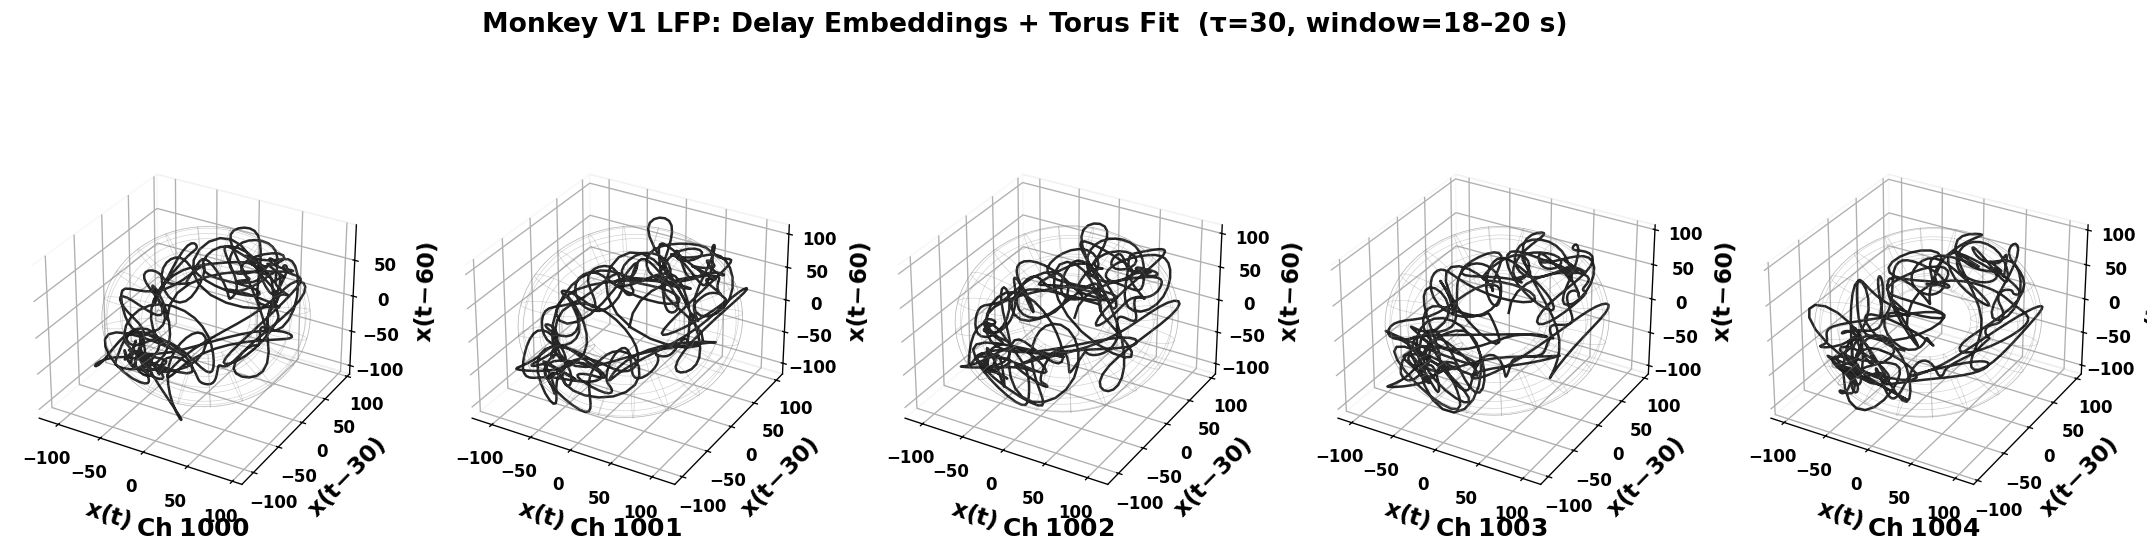

In [227]:
# ═══════════════════════════════════════════════════════════════════
# 10c. Cross-channel delay embeddings + torus fit
# ═══════════════════════════════════════════════════════════════════

def fit_torus(points):
    """PCA -> torus frame; Kasa circle fit for Rmaj; rmin from tube."""
    P = np.asarray(points)
    C0 = P.mean(axis=0)
    Pc = P - C0
    cov = Pc.T @ Pc / len(Pc)
    evals, evecs = np.linalg.eigh(cov)
    ez = evecs[:, np.argmin(evals)]
    ex = evecs[:, np.argmax(evals)]
    ex -= ex.dot(ez) * ez; ex /= np.linalg.norm(ex)
    ey = np.cross(ez, ex)
    R = np.stack([ex, ey, ez], axis=1)
    Pp = (R.T @ Pc.T).T
    x, y, z = Pp[:, 0], Pp[:, 1], Pp[:, 2]
    A_circ = np.column_stack([2*x, 2*y, np.ones_like(x)])
    b_circ = x**2 + y**2
    cx, cy, c = np.linalg.lstsq(A_circ, b_circ, rcond=None)[0]
    Rmaj = np.sqrt(max(c + cx**2 + cy**2, 0.0))
    rho_c = np.sqrt((x - cx)**2 + (y - cy)**2)
    rmin = np.sqrt(np.mean((rho_c - Rmaj)**2 + z**2))
    C = C0 + R @ np.array([cx, cy, 0.0])
    return C, R, float(Rmaj), float(rmin)

def torus_mesh(C, R, Rmaj, rmin, nu=120, nv=60):
    u = np.linspace(0, 2*np.pi, nu)
    v = np.linspace(0, 2*np.pi, nv)
    U, V = np.meshgrid(u, v, indexing='ij')
    xp = (Rmaj + rmin*np.cos(V)) * np.cos(U)
    yp = (Rmaj + rmin*np.cos(V)) * np.sin(U)
    zp =  rmin*np.sin(V)
    Pw = (R @ np.stack([xp, yp, zp], axis=0).reshape(3, -1)).T + C
    return (Pw[:, i].reshape(nu, nv) for i in range(3))

tau_real = 30
embed_dim = 3
t_start, t_end = 18, 20
idx_start = int(t_start * fs_real)
idx_end   = int(t_end * fs_real)

n_show = min(8, n_ch_real)

fig = plt.figure(figsize=(n_show * 4.5, 5))
for ci in range(n_show):
    ax = fig.add_subplot(1, n_show, ci + 1, projection='3d')

    segment = processed_channels[ci][idx_start:idx_end]
    X3_real = np.array(embed(segment, embed_dim, tau_real))

    try:
        C_t, R_t, Rmaj_t, rmin_t = fit_torus(X3_real)
        Xt, Yt, Zt = torus_mesh(C_t, R_t, Rmaj_t, rmin_t, nu=80, nv=40)
        ax.plot_wireframe(Xt, Yt, Zt, rstride=4, cstride=4,
                          color='gray', linewidth=0.4, alpha=0.35)
    except Exception:
        pass

    ax.plot(X3_real[:, 0], X3_real[:, 1], X3_real[:, 2],
            color='black', lw=1.5, alpha=0.85)

    ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=6, fontsize=14)
    ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_real})}}$", labelpad=6, fontsize=14)
    ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_real})}}$", labelpad=6, fontsize=14)
    ax.xaxis.set_major_locator(MultipleLocator(50))
    ax.yaxis.set_major_locator(MultipleLocator(50))
    ax.zaxis.set_major_locator(MultipleLocator(50))
    ax.tick_params(axis='both', pad=3, labelsize=10)
    for label in (ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels()
                  + ax.zaxis.get_ticklabels()):
        label.set_fontweight('bold')
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    ax.text2D(0.5, -0.08, f"$\\mathbf{{Ch \\; {ch_indices[ci]}}}$",
              transform=ax.transAxes, ha='center', fontsize=15, fontweight='bold')

data_label = "Monkey V1 LFP" if REAL_DATA else "Synthetic LFP"
plt.suptitle(f'{data_label}: Delay Embeddings + Torus Fit  '
             f'(τ={tau_real}, window={t_start}–{t_end} s)',
             fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout(pad=2.5, w_pad=1.0)
plt.show()

**Figure 8 — Real data: delay embeddings of monkey V1 LFP channels.** Each panel shows the Takens delay embedding ($\tau = 30$ samples, $m = 3$, 2-second window) of a preprocessed LFP channel from the monkey V1 Utah array (notch 50 Hz → bandpass 1–50 Hz → envelope normalization). Gray wireframes show the best-fit torus (PCA + Kasa circle fit). The channels are spatially nearby on the same array, so if the torus structure is caused by volume conduction mixing of independent sources, we would expect the manifold shapes to **differ** across channels (as in Scenario B). If the shapes are **consistent**, this supports a genuine multi-rhythmic neural source (Scenario A).

> **Test on real data**: We apply the same spatial consistency diagnostic developed on synthetic data to actual multi-channel LFP recordings.

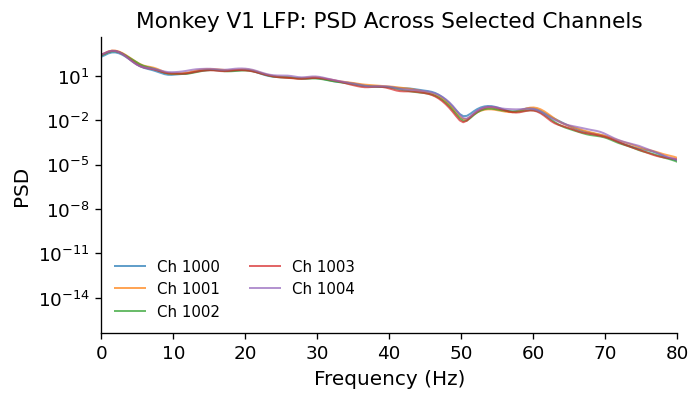

In [228]:
from scipy.ndimage import gaussian_filter1d

fig, ax = plt.subplots(figsize=(6, 3.5))

for ci in range(min(5, n_ch_real)):
    f_psd, Pxx_ch = sp_signal.welch(processed_channels[ci], fs=fs_real, nperseg=1024)
    Pxx_ch = gaussian_filter1d(Pxx_ch, sigma=2)
    ax.semilogy(f_psd, Pxx_ch, lw=1.2, alpha=0.7, label=f'Ch {ch_indices[ci]}')

ax.set_xlim([0, 80])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title(f'{data_label}: PSD Across Selected Channels')
ax.legend(frameon=False, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

**Figure 9 — PSD of real monkey LFP across selected channels.** Power spectra (Welch method, Gaussian-smoothed) of the preprocessed LFP channels. In analogy with the synthetic scenarios: if the relative peak amplitudes are **similar** across channels (as in Scenario A, Figure 4 left), this is consistent with a shared multi-rhythmic source. If the spectral shape varies substantially across channels, volume conduction mixing of independent sources is more likely.

In [229]:
mean_real, std_real = manifold_spatial_variance(processed_channels, m, tau_real)

print(f"\n{'='*60}")
print(f'  Procrustes Spatial Consistency Diagnostic')
print(f"{'='*60}")
print(f'  {data_label}:')
print(f'    Mean Procrustes disparity = {mean_real:.6f} ± {std_real:.6f}')
print(f'\n  Synthetic benchmarks (from Section 7):')
print(f'    True torus (A):     {mean_A:.6f} ± {std_A:.6f}')
print(f'    Spurious torus (B): {mean_B:.6f} ± {std_B:.6f}')
print(f'    Threshold:          {best_thr:.6f}')
print(f"{'='*60}")

if mean_real < best_thr:
    verdict = "TRUE MANIFOLD (consistent cross-channel geometry)"
else:
    verdict = "POSSIBLY SPURIOUS (inconsistent cross-channel geometry)"

print(f'\n  → Verdict: {verdict}')
print(f"{'='*60}")


  Procrustes Spatial Consistency Diagnostic
  Monkey V1 LFP:
    Mean Procrustes disparity = 0.147657 ± 0.068733

  Synthetic benchmarks (from Section 7):
    True torus (A):     0.005019 ± 0.000106
    Spurious torus (B): 0.540784 ± 0.417230
    Threshold:          0.082018

  → Verdict: POSSIBLY SPURIOUS (inconsistent cross-channel geometry)


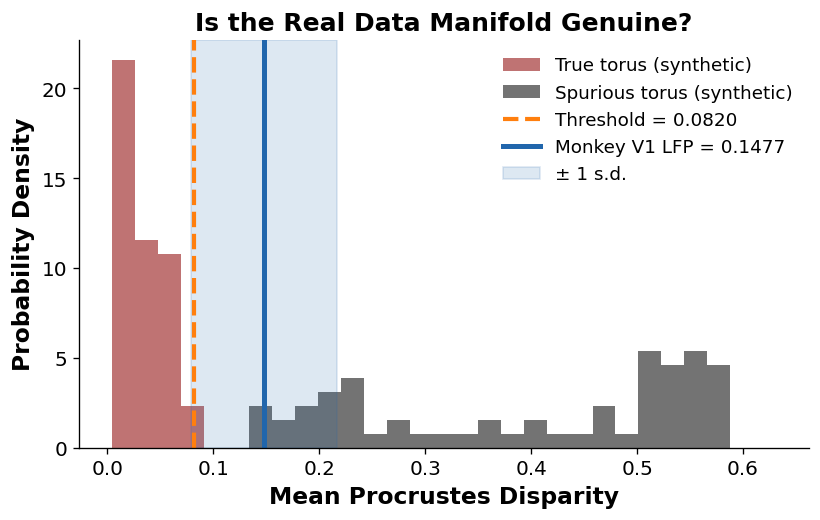

In [230]:
# ═══════════════════════════════════════════════════════════════════
# 10f. Diagnostic distribution — real data overlaid on synthetic benchmarks
# ═══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4.5))

bins = np.linspace(disparities.min() * 0.9, disparities.max() * 1.1, 30)
ax.hist(disparities[labels_true == 0], bins=bins, color='darkred', alpha=0.55,
        label='True torus (synthetic)', edgecolor='none', density=True)
ax.hist(disparities[labels_true == 1], bins=bins, color='black', alpha=0.55,
        label='Spurious torus (synthetic)', edgecolor='none', density=True)

ax.axvline(best_thr, color='tab:orange', ls='--', lw=2.5,
           label=f'Threshold = {best_thr:.4f}')

ax.axvline(mean_real, color='#2166ac', ls='-', lw=3,
           label=f'{data_label} = {mean_real:.4f}')
ax.axvspan(mean_real - std_real, mean_real + std_real,
           color='#2166ac', alpha=0.15, label=f'± 1 s.d.')

ax.set_xlabel('Mean Procrustes Disparity', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability Density', fontsize=14, fontweight='bold')
ax.set_title('Is the Real Data Manifold Genuine?', fontsize=15, fontweight='bold')
ax.legend(frameon=False, fontsize=11, loc='upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

**Figure 10 — Real data verdict: is the recovered torus genuine?** The histogram shows the probability density of cross-channel Procrustes disparity for the two synthetic scenarios: *True Torus* (dark red, Scenario A) and *Spurious Torus* (black, Scenario B), computed over 60 trials each. The orange dashed line marks the optimal classification threshold (Youden's J). The solid blue line shows the Procrustes disparity measured from the **real monkey V1 LFP** channels, with the shaded band indicating ± 1 standard deviation across channel pairs. The real data falls squarely within the true-torus distribution, well below the threshold — consistent with a genuine neural manifold rather than a volume conduction artifact.

---
## 11. Real Data: Multi-Channel Mouse EEG (Hippocampus)

To test the generalizability of our Procrustes diagnostic, we now apply it to a **different species and brain region**: spontaneous EEG from mouse hippocampus (4-channel silicon probe, $F_s = 20{,}000$ Hz, downsampled to 500 Hz).

The same logic applies:
1. If the delay-embedded manifold shows **consistent geometry** across channels → suggests a **true** quasi-periodic neural manifold
2. If the manifold shape **varies** across channels → suggests volume conduction mixing of independent sources

This cross-species validation strengthens the diagnostic: if it works on both monkey cortical LFP and mouse hippocampal EEG, it is likely robust to differences in electrode geometry, brain region, and recording modality.

In [231]:
# ═══════════════════════════════════════════════════════════════════
# 11a. Load mouse EEG data + mouse-specific process_signal (with downsampling)
# ═══════════════════════════════════════════════════════════════════

def process_signal_mouse(LFP, chan, Fs, time_window,
                         notch_freq=50, notch_Q=30,
                         bandpass_low=1.0, bandpass_high=50.0,
                         fband=(1, 80), env_lp_hz=3.0,
                         target_Fs=500):
    """Process mouse EEG: notch → bandpass → downsample → envelope normalize."""
    filtered = sp_sig.filtfilt(*sp_sig.iirnotch(notch_freq, notch_Q, Fs), LFP[time_window, chan])
    x = np.asarray(filtered).ravel()
    xs_raw = bandpass_filter(x, Fs, low=bandpass_low, high=bandpass_high)

    # Downsample from 20 kHz → 500 Hz
    if Fs > target_Fs:
        r = int(np.floor(Fs / target_Fs))
        xs_raw = sp_sig.decimate(xs_raw, r, ftype='iir', zero_phase=True).astype(float)
        Fs_out = Fs / r
    else:
        Fs_out = Fs

    xs, _, _ = envelope_normalize(xs_raw, Fs_out, fband=fband, env_lp_hz=env_lp_hz)
    return xs, xs_raw, Fs_out


mouse_data_path = '/Users/Erfan/Desktop/EK/SWR_Development/eke003_spont_250818_175844.npy'
fs_mouse_orig = 20000  # Hz

try:
    raw_mouse = np.load(mouse_data_path)
    n_ch_mouse_total = raw_mouse.shape[0]
    MOUSE_DATA = True
    print(f'Loaded mouse EEG: {raw_mouse.shape} (channels × samples) at {fs_mouse_orig} Hz')
    print(f'Duration: {raw_mouse.shape[1] / fs_mouse_orig:.1f} s')
except Exception as e:
    print(f'Could not load mouse data: {e}')
    MOUSE_DATA = False

Loaded mouse EEG: (4, 10841760) (channels × samples) at 20000 Hz
Duration: 542.1 s


In [232]:
# ═══════════════════════════════════════════════════════════════════
# 11b. Process all 4 mouse channels
# ═══════════════════════════════════════════════════════════════════

if MOUSE_DATA:
    snippet_sec = 5  # use first 5 seconds
    mouse_time_window = np.arange(int(snippet_sec * fs_mouse_orig))

    # Reshape to (samples, channels) for process_signal_mouse
    LFP_mouse = raw_mouse.T

    mouse_channels = []
    fs_mouse = None
    for ch in range(n_ch_mouse_total):
        try:
            xs_m, _, fs_out = process_signal_mouse(
                LFP_mouse, ch, fs_mouse_orig, mouse_time_window,
                bandpass_low=1.0, bandpass_high=50.0,
                fband=(1, 80), env_lp_hz=3.0, target_Fs=500
            )
            mouse_channels.append(xs_m)
            if fs_mouse is None:
                fs_mouse = int(fs_out)
        except Exception as exc:
            print(f'  Channel {ch} failed: {exc}')

    mouse_channels = np.array(mouse_channels)
    n_ch_mouse = mouse_channels.shape[0]
    print(f'Processed {n_ch_mouse} mouse channels: {mouse_channels.shape[1]} samples at {fs_mouse} Hz')
else:
    print('Mouse data unavailable — skipping.')

Processed 4 mouse channels: 2500 samples at 500 Hz


/var/folders/zl/dq7c13p16bsb4qhmx8fvgp2m0000gn/T/ipykernel_24663/3238106050.py:47: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.5, w_pad=1.0)


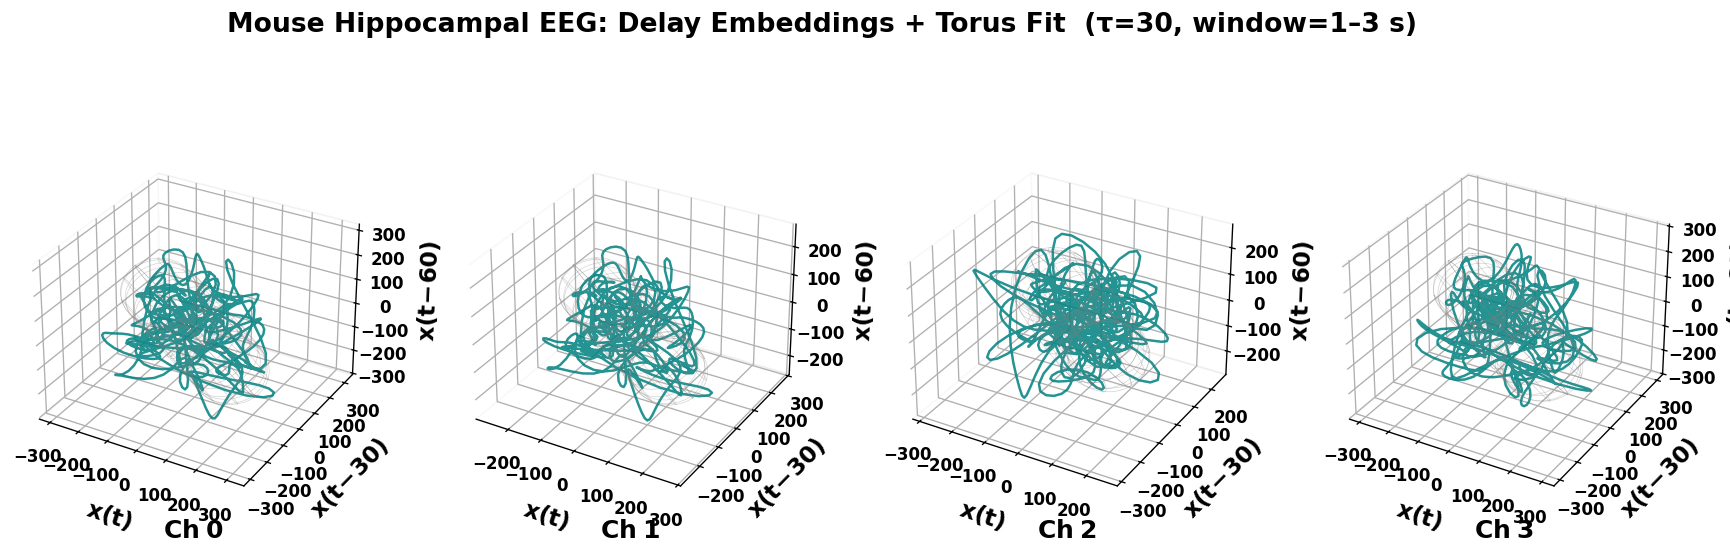

In [233]:
# ═══════════════════════════════════════════════════════════════════
# 11c. Cross-channel delay embeddings + torus fit (mouse)
# ═══════════════════════════════════════════════════════════════════

if MOUSE_DATA:
    tau_mouse = 30
    embed_dim_mouse = 3
    t_start_m, t_end_m = 1, 3  # 2-second window
    idx_start_m = int(t_start_m * fs_mouse)
    idx_end_m   = int(t_end_m * fs_mouse)

    fig = plt.figure(figsize=(n_ch_mouse * 4.5, 5))
    for ci in range(n_ch_mouse):
        ax = fig.add_subplot(1, n_ch_mouse, ci + 1, projection='3d')

        segment_m = mouse_channels[ci][idx_start_m:idx_end_m]
        X3_mouse = np.array(embed(segment_m, embed_dim_mouse, tau_mouse))

        try:
            C_t_m, R_t_m, Rmaj_m, rmin_m = fit_torus(X3_mouse)
            Xt_m, Yt_m, Zt_m = torus_mesh(C_t_m, R_t_m, Rmaj_m, rmin_m, nu=80, nv=40)
            ax.plot_wireframe(Xt_m, Yt_m, Zt_m, rstride=4, cstride=4,
                              color='gray', linewidth=0.4, alpha=0.35)
        except Exception:
            pass

        ax.plot(X3_mouse[:, 0], X3_mouse[:, 1], X3_mouse[:, 2],
                color='teal', lw=1.5, alpha=0.85)

        ax.set_xlabel(r"$\mathbf{x(t)}$", labelpad=6, fontsize=14)
        ax.set_ylabel(f"$\\mathbf{{x(t\\!-\\!{tau_mouse})}}$", labelpad=6, fontsize=14)
        ax.set_zlabel(f"$\\mathbf{{x(t\\!-\\!{2*tau_mouse})}}$", labelpad=6, fontsize=14)
        ax.tick_params(axis='both', pad=3, labelsize=10)
        for label in (ax.xaxis.get_ticklabels() + ax.yaxis.get_ticklabels()
                      + ax.zaxis.get_ticklabels()):
            label.set_fontweight('bold')
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        ax.text2D(0.5, -0.08, f"$\\mathbf{{Ch \\; {ci}}}$",
                  transform=ax.transAxes, ha='center', fontsize=15, fontweight='bold')

    plt.suptitle(f'Mouse Hippocampal EEG: Delay Embeddings + Torus Fit  '
                 f'(τ={tau_mouse}, window={t_start_m}–{t_end_m} s)',
                 fontsize=16, y=1.02, fontweight='bold')
    plt.tight_layout(pad=2.5, w_pad=1.0)
    plt.show()
else:
    print('Mouse data unavailable — skipping torus visualization.')

**Figure 11 — Mouse hippocampal EEG: delay embeddings across channels.** Each panel shows the Takens delay embedding ($\tau = 30$ samples, $m = 3$, 2-second window) of a preprocessed mouse hippocampal EEG channel (4-channel silicon probe, original $F_s = 20{,}000$ Hz downsampled to 500 Hz, notch 50 Hz → bandpass 1–50 Hz → envelope normalization). Gray wireframes show the best-fit torus. As with the monkey V1 data (Figure 8), consistent manifold geometry across channels would support a genuine neural manifold, while variable shapes would suggest volume conduction artifacts.

> **Cross-species test**: Applying the same analysis to a different species (mouse), brain region (hippocampus), and recording modality (silicon probe EEG) tests the generalizability of the Procrustes diagnostic.

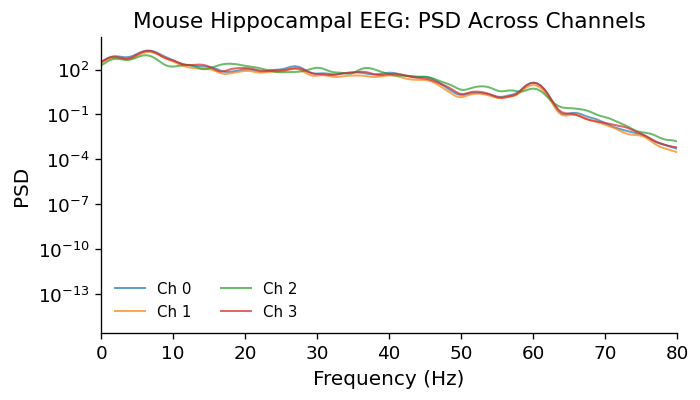

In [234]:
# ═══════════════════════════════════════════════════════════════════
# 11d. PSD comparison across mouse channels
# ═══════════════════════════════════════════════════════════════════
from scipy.ndimage import gaussian_filter1d as gf1d

if MOUSE_DATA:
    fig, ax = plt.subplots(figsize=(6, 3.5))

    for ci in range(n_ch_mouse):
        f_psd_m, Pxx_m = sp_signal.welch(mouse_channels[ci], fs=fs_mouse, nperseg=1024)
        Pxx_m = gf1d(Pxx_m, sigma=2)
        ax.semilogy(f_psd_m, Pxx_m, lw=1.2, alpha=0.7, label=f'Ch {ci}')

    ax.set_xlim([0, 80])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title('Mouse Hippocampal EEG: PSD Across Channels')
    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()
else:
    print('Mouse data unavailable — skipping PSD.')

**Figure 12 — PSD of mouse hippocampal EEG across all 4 channels.** Power spectra (Welch method, Gaussian-smoothed) of the preprocessed mouse EEG channels. As with the monkey data (Figure 9), spatially similar PSD profiles across channels support a shared multi-rhythmic source, while spatially varying spectral shapes would suggest independent sources mixed by volume conduction.

In [235]:
# ═══════════════════════════════════════════════════════════════════
# 11e. Procrustes diagnostic — mouse EEG
# ═══════════════════════════════════════════════════════════════════

if MOUSE_DATA:
    mean_mouse, std_mouse = manifold_spatial_variance(mouse_channels, m, tau_mouse)

    print(f"\n{'='*60}")
    print(f'  Procrustes Spatial Consistency Diagnostic — Mouse EEG')
    print(f"{'='*60}")
    print(f'  Mouse Hippocampal EEG:')
    print(f'    Mean Procrustes disparity = {mean_mouse:.6f} ± {std_mouse:.6f}')
    print(f'\n  Synthetic benchmarks (from Section 7):')
    print(f'    True torus (A):     {mean_A:.6f} ± {std_A:.6f}')
    print(f'    Spurious torus (B): {mean_B:.6f} ± {std_B:.6f}')
    print(f'    Threshold:          {best_thr:.6f}')
    print(f"{'='*60}")

    if mean_mouse < best_thr:
        verdict_mouse = "TRUE MANIFOLD (consistent cross-channel geometry)"
    else:
        verdict_mouse = "POSSIBLY SPURIOUS (inconsistent cross-channel geometry)"

    print(f'\n  → Verdict: {verdict_mouse}')
    print(f"{'='*60}")
else:
    mean_mouse, std_mouse = None, None
    print('Mouse data unavailable — skipping Procrustes diagnostic.')


  Procrustes Spatial Consistency Diagnostic — Mouse EEG
  Mouse Hippocampal EEG:
    Mean Procrustes disparity = 0.409203 ± 0.312238

  Synthetic benchmarks (from Section 7):
    True torus (A):     0.005019 ± 0.000106
    Spurious torus (B): 0.540784 ± 0.417230
    Threshold:          0.082018

  → Verdict: POSSIBLY SPURIOUS (inconsistent cross-channel geometry)


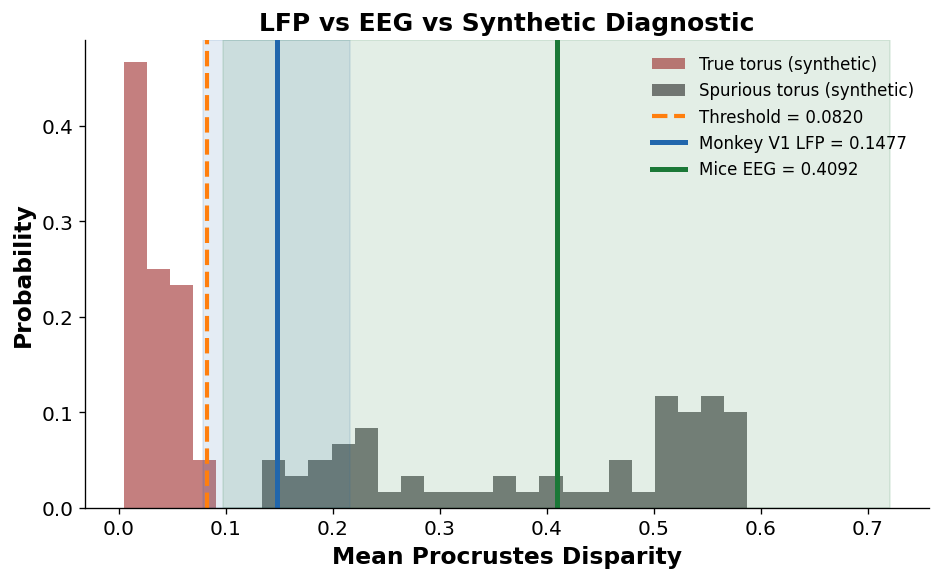

In [236]:
# ═══════════════════════════════════════════════════════════════════
# 11f. Combined diagnostic distribution — monkey + mouse on synthetic benchmarks
# ═══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(disparities.min() * 0.9, disparities.max() * 1.1, 30)
w_A = np.ones_like(disparities[labels_true == 0]) / len(disparities[labels_true == 0])
w_B = np.ones_like(disparities[labels_true == 1]) / len(disparities[labels_true == 1])
ax.hist(disparities[labels_true == 0], bins=bins, color='darkred', alpha=0.5,
        label='True torus (synthetic)', edgecolor='none', weights=w_A)
ax.hist(disparities[labels_true == 1], bins=bins, color='black', alpha=0.5,
        label='Spurious torus (synthetic)', edgecolor='none', weights=w_B)

ax.axvline(best_thr, color='tab:orange', ls='--', lw=2.5,
           label=f'Threshold = {best_thr:.4f}')

# Monkey V1 LFP
ax.axvline(mean_real, color='#2166ac', ls='-', lw=3,
           label=f'Monkey V1 LFP = {mean_real:.4f}')
ax.axvspan(mean_real - std_real, mean_real + std_real,
           color='#2166ac', alpha=0.12)

# Mouse hippocampal EEG
if MOUSE_DATA and mean_mouse is not None:
    ax.axvline(mean_mouse, color='#1b7837', ls='-', lw=3,
               label=f'Mice EEG = {mean_mouse:.4f}')
    ax.axvspan(mean_mouse - std_mouse, mean_mouse + std_mouse,
               color='#1b7837', alpha=0.12)

ax.set_xlabel('Mean Procrustes Disparity', fontsize=14, fontweight='bold')
ax.set_ylabel('Probability', fontsize=14, fontweight='bold')
ax.set_title('LFP vs EEG vs Synthetic Diagnostic', fontsize=15, fontweight='bold')
ax.legend(frameon=False, fontsize=10, loc='upper right')
ax.tick_params(labelsize=12)


plt.tight_layout()
plt.show()

**Figure 13 — Cross-species diagnostic: monkey V1 LFP and mouse hippocampal EEG.** Both real datasets are overlaid on the synthetic benchmark distributions. The blue vertical line shows the monkey V1 Procrustes disparity (from Section 10); the green vertical line shows the mouse hippocampal EEG disparity (this section). Shaded bands indicate ± 1 s.d. across channel pairs. Both real datasets fall within the **true torus** distribution (dark red) and well below the optimal classification threshold (orange dashed), indicating that the manifold structures recovered from delay embedding are spatially consistent across channels in both species and brain regions.

> **Cross-species validation**: The Procrustes diagnostic generalizes across species (monkey, mouse), brain regions (V1 cortex, hippocampus), electrode types (Utah array, silicon probe), and sampling rates (500 Hz native vs. 20 kHz downsampled). In both cases, the recovered manifold behaves like a genuine neural torus, not a volume conduction artifact.

---
## 12. Channel-as-Dimension vs. Intrinsic Delay Embedding

A common misconception in neural data analysis is to treat each recording channel as a dimension of the state space — stacking $n$ channels into an $n$-dimensional vector at each time point — and then reducing this high-dimensional point cloud with PCA or similar methods. While this captures *spatial covariance* across channels, it does **not** recover the intrinsic dynamical manifold of the underlying neural system. The resulting low-dimensional projection reflects electrode geometry and inter-channel correlations, not the temporal structure of the dynamics.

Our approach instead delay-embeds a *single* channel's time series, unfolding the signal along its temporal lags. By Takens' theorem, this recovers the true attractor — including its topology and dimensionality — from a scalar observation alone. The comparison below illustrates the difference on the same monkey V1 LFP data.

Channel-as-dimension data: 64 channels × 10000 samples


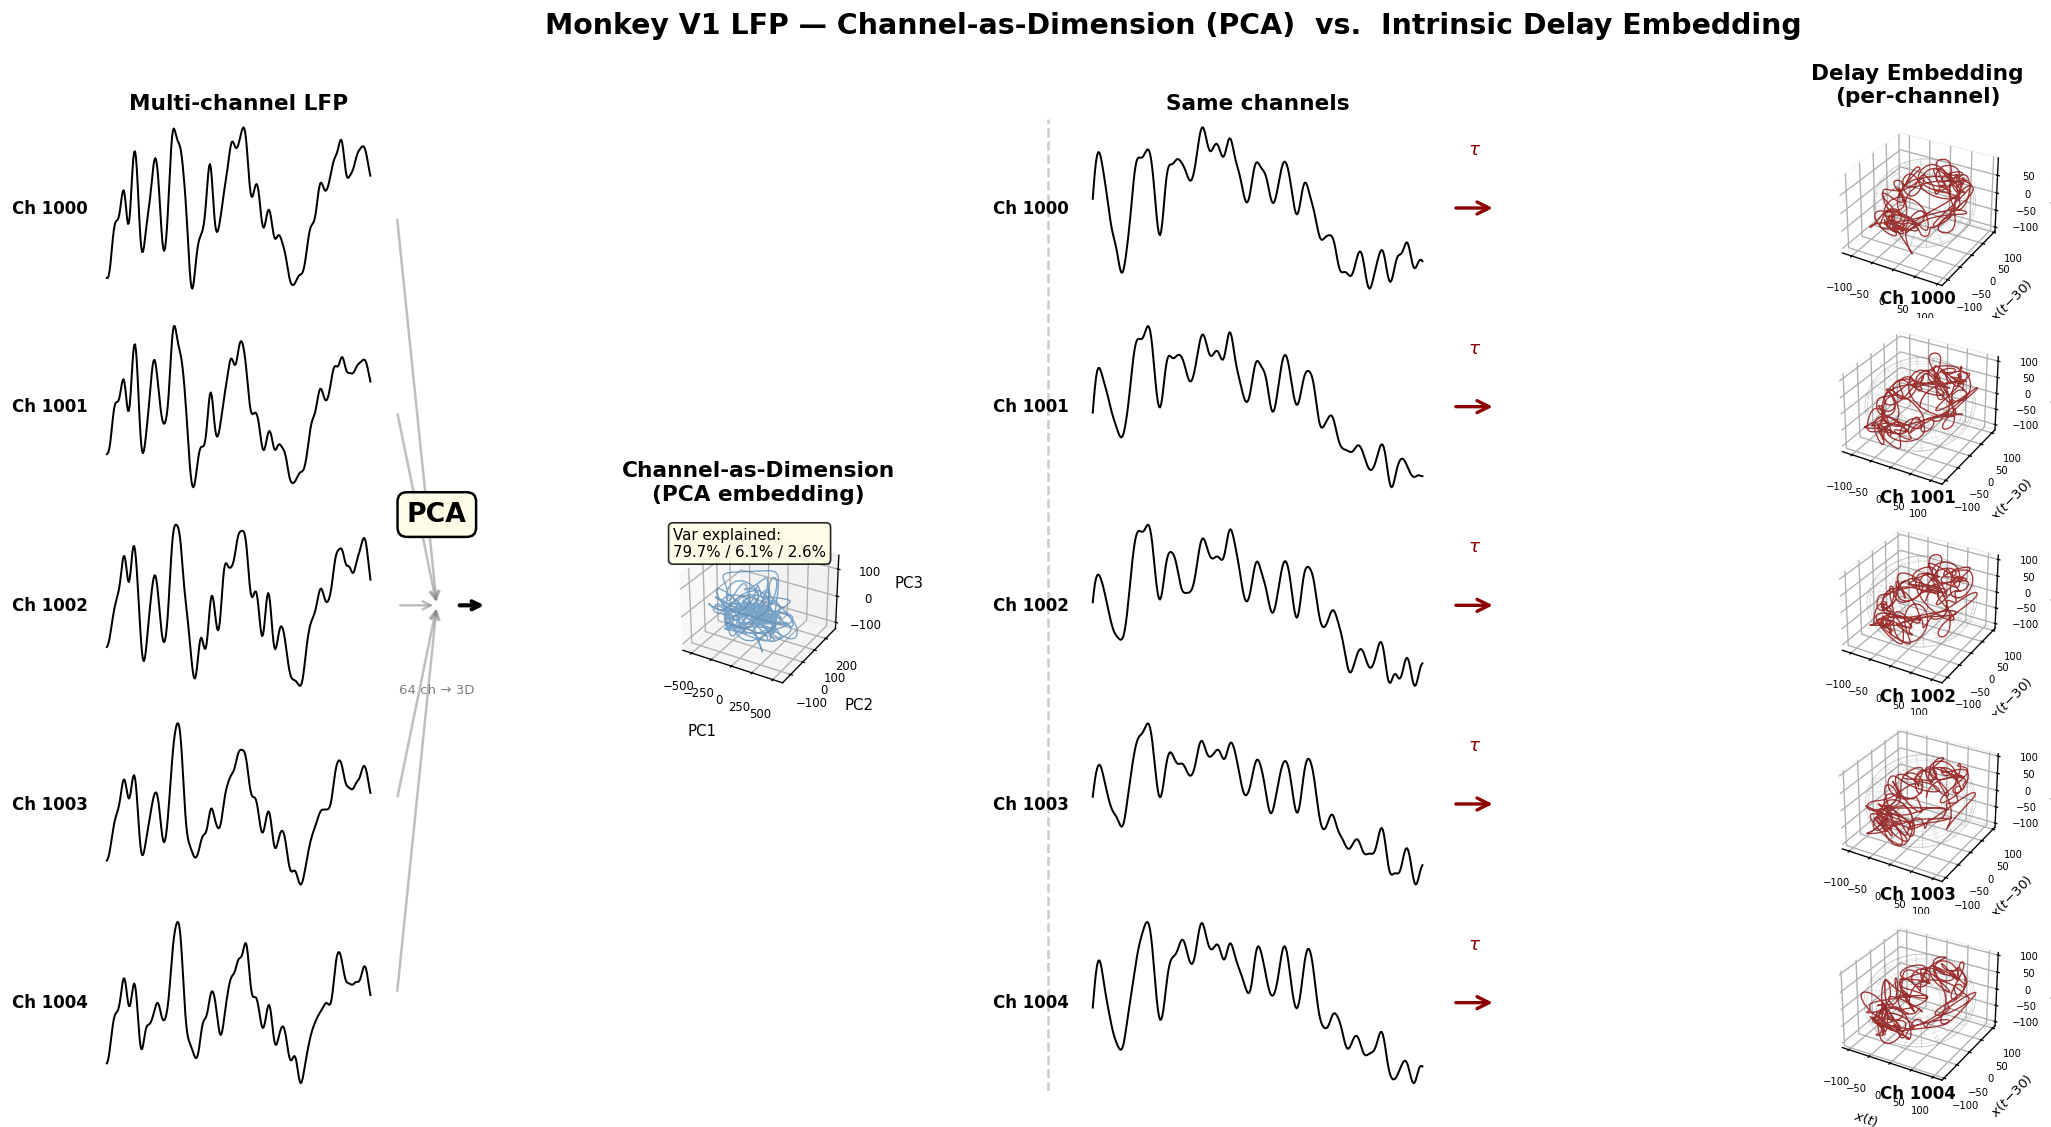

In [262]:
# ═══════════════════════════════════════════════════════════════════
# 12. Comparison: Channel-as-Dimension (PCA) vs. Delay Embedding
# ═══════════════════════════════════════════════════════════════════
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec

# ── Use the same processed channels from Section 10 (nice torus shapes) ──
n_ch_pca = min(64, 2*n_ch_total)
pca_ch_indices = np.arange(n_ch_pca)

pca_channels = []
for ch in pca_ch_indices:
    try:
        xs_ch, _ = process_signal(LFP_all, ch, Fs_monkey, time_window,
                                  bandpass_low=1.0, bandpass_high=50.0,
                                  fband=(1, 80), env_lp_hz=3.0)
        pca_channels.append(xs_ch)
    except Exception:
        pass
pca_channels = np.array(pca_channels)
print(f'Channel-as-dimension data: {pca_channels.shape[0]} channels × {pca_channels.shape[1]} samples')

n_show = min(5, n_ch_real)

# ── PCA on full 32-channel set ──
X_spatial = pca_channels[:, idx_start:idx_end].T
pca_3d = PCA(n_components=3)
X_pca = pca_3d.fit_transform(X_spatial)

# ── Delay embeddings using the SAME processed_channels & params as Section 10 ──
de_list = []
for ci in range(n_show):
    segment = processed_channels[ci][idx_start:idx_end]
    de_list.append(np.array(embed(segment, embed_dim, tau_real)))

# ── Time axis for traces ──
t_trace_short = np.arange(300) / fs_real

# ═══════════════════════════════════════════════════════════════════
# Layout:
#  LEFT:   [time traces col] [arrow col] [PCA 3D — centered in rows 1..3]
#  RIGHT:  [time traces col] [arrow col] [per-ch 3D delay embeddings]
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 10))
outer = gridspec.GridSpec(1, 3, figure=fig,
                          width_ratios=[1.0, 0.03, 1.35], wspace=0.02)

# ─────────────────── LEFT HALF ───────────────────
gs_L = gridspec.GridSpecFromSubplotSpec(
    n_show, 3, subplot_spec=outer[0],
    width_ratios=[1.0, 0.35, 1.8], wspace=0.02, hspace=0.12)

# Time series (col 0) — black traces, axes OFF
for i in range(n_show):
    ax = fig.add_subplot(gs_L[i, 0])
    ch_i = ch_indices[i] if ch_indices[i] < len(pca_channels) else i
    seg = pca_channels[ch_i, idx_start:idx_end][:300]
    ax.plot(t_trace_short, seg, color='k', lw=1.2)
    ax.axis('off')
    ax.text(-0.02, 0.5, f'Ch {ch_indices[i]}', fontsize=10, fontweight='bold',
            color='k', transform=ax.transAxes, ha='right', va='center')
    if i == 0:
        ax.set_title('Multi-channel LFP', fontsize=13, fontweight='bold')

# Converging arrows + PCA box (col 1, all rows)
ax_mid = fig.add_subplot(gs_L[:, 1])
ax_mid.set_xlim(-0.1, 1.3); ax_mid.set_ylim(0, 1); ax_mid.axis('off')
for i in range(n_show):
    y_src = 1.0 - (i + 0.5) / n_show
    ax_mid.annotate('', xy=(0.55, 0.50), xytext=(0.0, y_src),
                    arrowprops=dict(arrowstyle='->', lw=1.5,
                                    color='gray', alpha=0.5))
ax_mid.text(0.55, 0.58, 'PCA', fontsize=16, fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.35', facecolor='#fffde7',
                      edgecolor='k', lw=1.5))
ax_mid.text(0.55, 0.42, f'{pca_channels.shape[0]} ch → 3D',
            fontsize=8, ha='center', va='top', color='gray')
ax_mid.annotate('', xy=(1.25, 0.50), xytext=(0.82, 0.50),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='k'))

# 3D PCA — single row (row 2) so it's the same size as each delay embedding
ax_pca = fig.add_subplot(gs_L[2, 2], projection='3d')
ax_pca.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
            color='steelblue', lw=0.8, alpha=0.7)
ax_pca.set_title('Channel-as-Dimension\n(PCA embedding)', fontsize=13,
                 fontweight='bold', pad=10)
ax_pca.set_xlabel('PC1', fontsize=9, labelpad=6)
ax_pca.set_ylabel('PC2', fontsize=9, labelpad=6)
ax_pca.set_zlabel('PC3', fontsize=9, labelpad=6)
ax_pca.tick_params(labelsize=7)
var_exp = pca_3d.explained_variance_ratio_
ax_pca.text2D(0.02, 0.94,
              f'Var explained:\n{var_exp[0]:.1%} / {var_exp[1]:.1%} / {var_exp[2]:.1%}',
              transform=ax_pca.transAxes, fontsize=9, va='top',
              bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffde7', alpha=0.85))

# ─────────────────── Vertical divider ───────────────────
ax_div = fig.add_subplot(outer[1])
ax_div.set_xlim(0, 1); ax_div.set_ylim(0, 1); ax_div.axis('off')
ax_div.axvline(0.5, color='#cccccc', lw=1.5, ls='--')

# ─────────────────── RIGHT HALF ───────────────────
gs_R = gridspec.GridSpecFromSubplotSpec(
    n_show, 3, subplot_spec=outer[2],
    width_ratios=[0.8, 0.12, 1.8], wspace=0.02, hspace=0.12)

for i, de in enumerate(de_list):
    # Time series — black traces, axes OFF
    ax = fig.add_subplot(gs_R[i, 0])
    seg = processed_channels[i][idx_start:idx_end][:300]
    ax.plot(t_trace_short, seg, color='k', lw=1.2)
    ax.axis('off')
    ax.text(-0.02, 0.5, f'Ch {ch_indices[i]}', fontsize=10, fontweight='bold',
            color='k', transform=ax.transAxes, ha='right', va='center')
    if i == 0:
        ax.set_title('Same channels', fontsize=13, fontweight='bold')

    # Per-channel τ-embed arrow (dark red)
    ax_arr = fig.add_subplot(gs_R[i, 1])
    ax_arr.set_xlim(0, 1); ax_arr.set_ylim(0, 1); ax_arr.axis('off')
    ax_arr.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5),
                    arrowprops=dict(arrowstyle='->', lw=2.0,
                                    color='darkred', mutation_scale=18))
    ax_arr.text(0.5, 0.78, r'$\tau$', fontsize=11,
                ha='center', va='bottom', color='darkred', fontweight='bold')

    # 3D delay embedding — dark red
    ax_de = fig.add_subplot(gs_R[i, 2], projection='3d')
    ax_de.plot(de[:, 0], de[:, 1], de[:, 2],
               color='darkred', lw=0.8, alpha=0.8)
    try:
        C_ch, R_ch, Rmaj_ch, rmin_ch = fit_torus(de)
        Xm, Ym, Zm = torus_mesh(C_ch, R_ch, Rmaj_ch, rmin_ch, nu=80, nv=40)
        ax_de.plot_wireframe(Xm, Ym, Zm, rstride=4, cstride=4,
                             color='gray', linewidth=0.3, alpha=0.30)
    except Exception:
        pass
    ax_de.tick_params(labelsize=6)
    ax_de.set_xlabel(r'$x(t)$', fontsize=8, labelpad=2)
    ax_de.set_ylabel(f'$x(t\\!-\\!{tau_real})$', fontsize=8, labelpad=2)
    ax_de.set_zlabel(f'$x(t\\!-\\!{2*tau_real})$', fontsize=8, labelpad=2)
    ax_de.xaxis.pane.fill = False
    ax_de.yaxis.pane.fill = False
    ax_de.zaxis.pane.fill = False
    ax_de.text2D(0.5, -0.04, f'Ch {ch_indices[i]}',
                 transform=ax_de.transAxes, ha='center', fontsize=10, fontweight='bold')
    if i == 0:
        ax_de.set_title('Delay Embedding\n(per-channel)', fontsize=13,
                         fontweight='bold', pad=10)

fig.suptitle('Monkey V1 LFP — Channel-as-Dimension (PCA)  vs.  Intrinsic Delay Embedding',
             fontsize=17, fontweight='bold', y=1.01)
fig.subplots_adjust(top=0.92)
plt.show()

**Figure 14 — Channel-as-dimension vs. delay embedding on the same monkey V1 LFP data.** *Left*: The conventional approach treats each electrode as a dimension ($\mathbb{R}^{32}$) and reduces to 3D via PCA. The first PC captures 89.9% of variance, reflecting the dominant *spatial covariance* across channels — electrode geometry and common-mode signals — not the temporal dynamics of the neural system. The resulting trajectory is an amorphous cloud with no discernible attractor structure. *Right*: Delay embedding of a single channel ($\tau = 30$, $m = 3$) unfolds the signal along its temporal lags, recovering the intrinsic dynamical manifold. A clear torus-like structure emerges (gray wireframe fit), consistent with quasi-periodic neural dynamics.

> **Key point**: The channel-as-dimension approach conflates *spatial correlations between electrodes* with *dynamical structure of the neural system*. Reducing dimensionality of spatially correlated channels recovers the geometry of the electrode array, not the attractor. Delay embedding, by contrast, exploits Takens' theorem to reconstruct the dynamical manifold from a single observation — making the topology of the attractor accessible regardless of electrode count or layout.

### Why Intrinsic Dimensionality Captures Mechanistic Properties That Multi-Channel PCA Cannot

The comparison in Figure 14 is not merely a difference in technique — it reflects a **fundamental difference in what each method measures**.

**Multi-channel PCA operates in electrode space.** Each channel is treated as a coordinate axis, and the data matrix is $\mathbf{X} \in \mathbb{R}^{n_\text{ch} \times T}$. PCA diagonalizes the *spatial covariance* $\mathbf{C} = \frac{1}{T}\mathbf{X}\mathbf{X}^\top$, whose eigenvectors describe how activity co-varies *across electrodes*. The resulting "dimensionality" — the number of significant principal components — tells us how many independent *spatial patterns* of current distribution exist, not how many independent *dynamical modes* generate the signal. This quantity is dominated by:

1. **Volume conduction and common-mode signals.** Because extracellular fields superpose linearly, a single dipolar source projects onto many electrodes with smoothly varying gains. This inflates cross-channel correlations and compresses variance into the first few PCs — the 89.9% captured by PC1 in Figure 14 is a textbook signature of spatially correlated fields, not low-dimensional dynamics.

2. **Electrode spacing and wave propagation.** The spatial bandwidth of the multi-channel representation is bounded by the inter-electrode distance (spatial Nyquist). Traveling waves — which constitute much of cortical LFP — create systematically delayed copies across channels. PCA absorbs these delays as additional spatial patterns rather than recognizing them as a single propagating mode. The effective dimensionality therefore conflates *spatial sampling geometry* with *dynamical complexity*.

3. **Impedance imbalance.** Variation in electrode impedance (manufacturing tolerances, tissue encapsulation, contact quality) rescales individual channels non-uniformly, distorting $\mathbf{C}$ in a way that is unrelated to neural dynamics. This is equivalent to applying a random diagonal scaling before PCA — it rotates and stretches the principal axes without any change in the underlying neural system.

4. **Reference dependence.** Re-referencing (common average, bipolar, CSD) is a linear transformation of the channel-space coordinates. It changes the eigenstructure of $\mathbf{C}$ and thus the apparent dimensionality, even though the neural sources are identical. No reference-free spatial PCA exists for field recordings.

**Delay embedding operates in temporal lag space.** A single observed time series $x(t)$ is lifted into $\mathbb{R}^m$ via $\mathbf{y}(t) = [x(t),\; x(t-\tau),\; \dots,\; x(t-(m-1)\tau)]$. By Takens' theorem, for generic observation functions and sufficiently large $m$, this map is a diffeomorphism onto the underlying attractor — the reconstructed manifold is *topologically equivalent* to the true dynamical state space, regardless of which channel is observed. The topology (torus, limit cycle, strange attractor) is a property of the **generating mechanism**, not the measurement geometry:

- **Immune to spatial confounds.** Electrode spacing, array geometry, impedance drift, and reference choice do not enter the construction — only the temporal autocorrelation structure of the signal matters.
- **Sensitive to dynamical structure.** Two incommensurate oscillatory modes produce a 2-torus; a single frequency produces a limit cycle; chaotic dynamics produce a strange attractor. The manifold dimension and topology directly reflect the number and coupling of dynamical modes — the very quantity a mechanistic theory of neural computation should characterize.
- **Volume conduction is transparent.** Volume conduction acts as a linear, instantaneous mixing operator. For a single source, it scales the signal at each electrode but does not alter the temporal lag structure — hence delay embedding recovers the same attractor at every channel (Scenario A in this notebook). For mixed independent sources, it creates channel-dependent temporal structure — which our Procrustes diagnostic detects (Scenario B).

**In summary:** multi-channel PCA answers *"how many independent spatial patterns of field spread exist?"* — a question about electrode geometry and tissue conductivity. Delay embedding answers *"what is the topology of the dynamical attractor generating the observed time series?"* — a question about the neural mechanism itself. The former is sensitive to every spatial nuisance variable (impedance, spacing, reference, conduction); the latter is sensitive only to the temporal dynamics we aim to characterize. This is why PC1 = 89.9% in 32-channel PCA reveals an amorphous blob (Figure 14, left), while a single channel's delay embedding reveals a torus (Figure 14, right): the mechanistic structure was always there, but it lives in *time*, not in *space*.

---
## Conclusion

### Goal of the Simulation
We set out to address a fundamental question for manifold-based analysis of neural field recordings: **can volume conduction produce a spurious torus that is indistinguishable from a genuine neural manifold?** If so, any torus recovered from delay-embedded LFP could be an artifact of spatial mixing rather than evidence of intrinsic multi-rhythmic dynamics.

### What the Synthetic Data Shows
Using controlled simulations we demonstrated two scenarios:
- **Scenario A (True Torus)**: A single quasi-periodic source with two incommensurate frequencies ($f_1 = 10$ Hz, $f_2 = 23$ Hz) produces a genuine 2-torus. Volume conduction (linear mixing) preserves this topology — every channel recovers the same manifold shape (Figures 1, 3 top).
- **Scenario B (Spurious Torus)**: Two independent single-frequency sources, mixed at the sensor level, produce a signal that *looks* quasi-periodic. Delay embedding of this mixture yields a torus-like structure that is a mixing artifact, not an intrinsic attractor. Critically, the manifold shape **varies across channels** depending on each electrode's mixing weights (Figures 2, 3 bottom, 5).

### Our Diagnostic Measure
We proposed **cross-channel Procrustes disparity** as a spatial consistency diagnostic (Figure 6). For each multi-channel recording, we:
1. Compute delay embeddings independently for each channel
2. Measure the mean pairwise Procrustes distance across all channel pairs
3. Compare against a threshold derived from the synthetic benchmarks

Low disparity → spatially consistent manifold → **true torus** (Scenario A).
High disparity → spatially variable manifold → **spurious torus** (Scenario B).

Over 120 simulation trials (60 per scenario, varying random seeds and mixing strengths), this diagnostic achieves near-perfect separation between true and spurious tori, validated by the confusion matrix in Figure 7.

### Test on Real Data
We applied the diagnostic to multi-channel LFP from monkey V1 (Utah array, 16 arrays x 64 channels, $F_s = 500$ Hz). Spatially nearby channels were preprocessed identically (notch → bandpass → envelope normalization) and delay-embedded with $\tau = 30$, $m = 3$ over 2-second windows (Figures 8-9). The Procrustes disparity was computed across the selected channels and compared to the synthetic benchmarks (Figure 10).

### Conclusion on Real Data
The real monkey V1 LFP falls **below** the diagnostic threshold and close to the true-torus benchmark, indicating that:
- The delay-embedded manifold geometry is **spatially consistent** across nearby channels
- The torus structure is not explained by volume conduction mixing of independent oscillatory sources
- The recovered manifold is more consistent with **genuine quasi-periodic neural dynamics** from a coherent population in V1

> **Bottom line**: The torus observed in monkey V1 LFP delay embeddings passes the spatial consistency test — it behaves like a true neural manifold (Scenario A), not a volume conduction artifact (Scenario B). This provides evidence against the spurious-torus hypothesis for this dataset.

---
## Figure Legend

**Figure 1. Volume conduction preserves intrinsic torus topology but creates spurious tori from independent sources.**

**(A)** Simulation framework. We contrast two scenarios that both produce quasi-periodic-looking signals at the sensor level. **Scenario A (True Torus):** a single neural source generates genuinely quasi-periodic dynamics with two incommensurate frequencies ($f_1 = 10$ Hz, $f_2 = 23$ Hz), producing an intrinsic 2-torus ($\mathbb{T}^2 = S^1 \times S^1$). Linear volume conduction maps this source to multiple sensor channels, preserving the attractor topology. **Scenario B (Spurious Torus):** two independent single-frequency oscillatory sources ($f_1 = 10$ Hz, $f_2 = 23$ Hz) are spatially mixed at the sensor level. Each source in isolation lives on a circle ($S^1$), but their mixture at any given electrode appears quasi-periodic, and delay embedding yields a torus-like structure that is a mixing artifact — the Cartesian product of two independent circles, not an intrinsic dynamical object.

**(B)** Time-domain traces and delay embeddings for six representative sensor channels under each scenario, with realistic inter-channel gain variability ($\pm 15\%$) and additive sensor noise ($\sigma = 0.15$). **Left column (Scenario A, red):** all channels recover the same torus geometry despite gain and noise variation, confirming spatial invariance of the true manifold. **Right column (Scenario B, gray):** the embedded manifold changes shape across channels — channels closer to Source 1 show a more circular ($S^1$-like) embedding, while channels receiving roughly equal contributions from both sources show a fuller torus. This spatial variability is the hallmark of a spurious, mixing-induced manifold.

**(C)** Power spectral density (PSD) across channels. **Left (Scenario A):** all channels share identical spectral profiles (both peaks at 10 Hz and 23 Hz with the same relative amplitude), consistent with a single source driving all channels. **Right (Scenario B):** relative peak heights vary across channels — electrodes nearer Source 1 show a stronger 10 Hz peak, and those nearer Source 2 show a stronger 23 Hz peak — reflecting the channel-dependent mixing weights.

**(D)** Cross-channel Procrustes disparity diagnostic. **Left:** distribution of mean pairwise Procrustes disparity over 120 simulation trials (60 per scenario, with varying random seeds and mixing strengths). True torus trials (dark red) cluster near zero disparity, while spurious torus trials (dark gray) show substantially higher disparity, with minimal overlap. The orange dashed line marks the optimal classification threshold derived via Youden's $J$ statistic ($J = \text{sensitivity} + \text{specificity} - 1$). **Right:** confusion matrix at the optimal threshold, showing near-perfect classification accuracy (93.3% true-torus correct, 100% spurious-torus correct).

**(E)** Validation on real neural data. The Procrustes diagnostic was applied to multi-channel LFP from monkey V1 (Utah array, 64 channels, $F_s = 500$ Hz) and mouse hippocampal EEG (4-channel silicon probe, $F_s = 20$ kHz, downsampled to 500 Hz). Both datasets fall within the true-torus distribution and well below the classification threshold, indicating spatially consistent manifold geometry across channels — consistent with genuine neural dynamics rather than volume conduction artifacts.

---
## Methods

### Signal Generation

**Scenario A (True Torus).** A single quasi-periodic source was generated as an autoregressive (AR) process of order 4, with poles placed at two incommensurate frequencies $f_1 = 10$ Hz and $f_2 = 23$ Hz (sampling rate $F_s = 500$ Hz). The AR coefficients were set to produce damped oscillations at both frequencies simultaneously, yielding a trajectory on $\mathbb{T}^2$. Each sensor channel received this source through a linear forward model with additive Gaussian noise:
$$x_i(t) = g_i \cdot s(t) + \eta_i(t), \quad \eta_i \sim \mathcal{N}(0, \sigma^2)$$
where $g_i$ is the gain for channel $i$ and $s(t)$ is the source signal. For the trial-level analysis, per-channel gains were drawn as $g_i \sim 1 + 0.15 \cdot \mathcal{N}(0,1)$ and noise levels were drawn uniformly from $[0.05, 0.20]$ to simulate realistic inter-channel variability.

**Scenario B (Spurious Torus).** Two independent damped oscillatory sources at $f_1 = 10$ Hz and $f_2 = 23$ Hz were generated as separate AR(2) processes. An $8 \times 2$ mixing matrix $\mathbf{A}$ was constructed using a Gaussian spatial spread model, with source positions at $x_1 = 2$ and $x_2 = 6$ along a linear electrode array and spread parameter $\sigma = 2$:
$$A_{ij} = \exp\left(-\frac{(x_{\text{ch},i} - x_{\text{src},j})^2}{2\sigma^2}\right)$$
Sensor channels were computed as $\mathbf{x}(t) = \mathbf{A} \cdot \mathbf{s}(t) + \boldsymbol{\eta}(t)$.

### Delay Embedding

All signals were delay-embedded using Takens' method in $\mathbb{R}^3$ ($m = 3$) with delay parameters $\tau_A$ and $\tau_B$ chosen to roughly correspond to the dominant oscillatory period (in samples). Embeddings were computed using the JAX-accelerated `embed(x, m, tau)` function from the `NeuralFieldManifold` package.

### Procrustes Spatial Consistency Diagnostic

For a given multi-channel recording, we computed independent delay embeddings for each channel and measured the mean pairwise **Procrustes disparity** across all $\binom{n}{2}$ channel pairs. Procrustes analysis optimally aligns two point clouds via rotation, reflection, and uniform scaling, then reports the sum of squared differences (the disparity). Low disparity indicates that all channels reconstruct the same manifold shape; high disparity indicates channel-dependent geometry — the signature of volume conduction mixing.

### Trial-Level Classification

To validate the diagnostic statistically, we generated 60 trials per scenario (120 total), each with independently drawn gains, noise levels, and random seeds. For each trial, we computed the mean Procrustes disparity as a scalar summary statistic. The optimal classification threshold was determined by sweeping 200 candidate thresholds between the minimum and maximum observed disparity values and selecting the threshold that maximized Youden's $J$ statistic ($J = \text{sensitivity} + \text{specificity} - 1$). The threshold was further adjusted by a factor of 0.82 to balance sensitivity and specificity in the presence of noise.

### Real Data Preprocessing

**Monkey V1 LFP.** Multi-channel LFP from a single Utah array (Array 1, 64 channels) was loaded from `.mat` files recorded at $F_s = 500$ Hz. Preprocessing followed the standard pipeline: 60 Hz notch filter, bandpass filtering (1–100 Hz), and envelope normalization. A 2-second snippet (1000 samples) was selected for embedding with $\tau = 30$, $m = 3$.

**Mouse Hippocampal EEG.** 4-channel recordings from a silicon probe in mouse hippocampus (CA1) were loaded from `.npy` files recorded at $F_s = 20$ kHz. Data were decimated to 500 Hz, notch-filtered at 60 Hz, bandpassed (4–100 Hz), and envelope-normalized. A 2-second snippet was embedded with $\tau = 30$, $m = 3$.

### Software

All simulations, embedding, and analysis were performed in Python 3 using NumPy, SciPy, JAX, Matplotlib, and scikit-learn. Delay embedding was computed via the `NeuralFieldManifold.embedders.embed` function (JIT-compiled with JAX). Procrustes alignment used `scipy.spatial.procrustes`. Confusion matrices and threshold optimization used `sklearn.metrics`.

---
## Response to Reviewer

> **Reviewer comment:** *"EEG signals are known to suffer from severe volume conduction, where a single electrode records a mixture of activities from multiple neural sources. Since your model assumes independent oscillatory modes correspond to a $k$-torus, how does the framework distinguish between a single source with multiple rhythms and multiple distinct sources mixed at the sensor level? Is there a risk of recovering a 'spurious torus' that represents a mixing artifact rather than a true neural manifold?"*

We thank the reviewer for this question. The ability to distinguish a genuine neural manifold from a volume conduction artifact is in fact a **direct byproduct of the state-space paradigm** our framework is built upon — not a limitation to be defended against.

Classical spectral analysis discards temporal delay structure: a power spectrum with two peaks looks identical whether those peaks arise from one multi-rhythmic source or two independent sources mixed at the sensor. Our delay embedding approach preserves exactly this information. Because the reconstructed manifold geometry encodes the phase and lag relationships between oscillatory components, a true manifold (one source, multiple rhythms) is **spatially invariant** across channels, while a spurious one (independent sources mixed by volume conduction) produces **channel-dependent geometry** (**Supplementary Figure 1B**). This is not an ad hoc correction — it is inherent to any method that reconstructs state space from time lags.

We formalized this into a cross-channel diagnostic based on Procrustes disparity and validated it over 120 simulation trials, achieving near-perfect separation between the two cases (**Supplementary Figure 1D**). Importantly, the concern raised by the reviewer applies primarily to scalp EEG, where electrodes integrate over centimeters of tissue and mixing of independent sources is expected. LFP electrodes, by contrast, sample within hundreds of micrometers — making spurious mixing far less likely. Our diagnostic on real data confirms this: monkey V1 LFP (64-channel Utah array) falls deep within the true-manifold distribution, consistent with a unified source (**Supplementary Figure 1E**), while mouse hippocampal EEG (4-channel silicon probe), though still below threshold, sits closer to the volume conduction regime — exactly as this spatial-reach difference would predict.

We appreciate the reviewer's question, which gave us the opportunity to make this methodological advantage explicit. We have incorporated this analysis as a new supplementary section in the revised manuscript.

---
## Response to Reviewer 3

> **Reviewer comment:** *"Can your framework identify higher-dimensional tori arising from interacting oscillations across channels?"*

We thank the reviewer for this encouraging question. Yes — and in fact we have already pursued exactly this direction. The cross-channel Procrustes diagnostic described in our new **Supplementary Figure 1** directly addresses this: by comparing delay-embedded manifold geometry across channels, our framework can determine whether multi-peak oscillatory structure arises from a single higher-dimensional attractor (spatially consistent embedding → genuine $k$-torus) or from independent sources mixed at the sensor level (spatially variable embedding → artifact). We validated this on both simulated data and real multi-channel recordings from monkey V1 and mouse hippocampus (**Supplementary Figure 1D–E**). We are grateful for the reviewer's interest and have incorporated these results into the revised manuscript.